# ERM untied exp

In [13]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# run_id = "20251208_1356" # rho = 1 
run_id = "20251208_1034" # rho = 0.75

## 1. experiment config

In [14]:
# --- Path to your local folder ---
config_path = f"../results/run_{run_id}/config.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251208_1034/config.csv


,alpha,D,L,rho,rho_star,beta,lam,Delta_in,samples,T,learning_rate,norm_init,tol,N_test,base_dir
0,0.100000,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
1,0.164286,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
2,0.228571,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
3,0.292857,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
4,1.000000,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
5,0.357143,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
6,0.871429,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
7,0.935714,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
8,0.807143,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
9,0.421429,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (105 rows) from ../results/run_20251208_1034/summary.csv


,alpha,alpha_idx,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,label_err_mean_noise,label_err_std_noise,train_data_mean,train_reg_mean,train_total_mean,W_Q_runs,W_K_runs
0,0.1,0,0.1000,0.75,0.913697,0.005238,0.048513,0.000815,0.060459,0.000953,0.016882,0.010806,0.027688,"[array([[-0.45550618, 0.3424298 , -0.438587 ...","[array([[-0.52360654, 0.09844012, -0.15041131..."
1,0.1,0,0.0100,0.75,0.972231,0.012828,0.053616,0.001666,0.066402,0.001907,0.000794,0.004908,0.005702,"[array([[-0.20671618, -0.03756422, 1.4232041 ...","[array([[ 0.9726967 , -0.2844073 , -0.38750955..."
2,0.1,0,0.0050,0.75,0.951704,0.012863,0.053749,0.001560,0.067267,0.001803,0.000289,0.002781,0.003070,"[array([[ 0.33789575, 0.46130383, -0.93355674...","[array([[ 0.11879582, -0.23999867, 0.6584467 ..."
3,0.1,0,0.0010,0.75,1.076843,0.016944,0.060845,0.001047,0.073619,0.001688,0.000027,0.000661,0.000688,"[array([[ 0.46582195, 0.07073057, 0.7322208 ...","[array([[ 0.4713936 , -0.16761136, -0.17724074..."
4,0.1,0,0.0005,0.75,1.044003,0.014060,0.060052,0.001673,0.073293,0.001895,0.000009,0.000338,0.000347,"[array([[-0.84148026, 0.42954883, -0.08136512...","[array([[-0.05430537, 0.67203075, 0.57719624..."


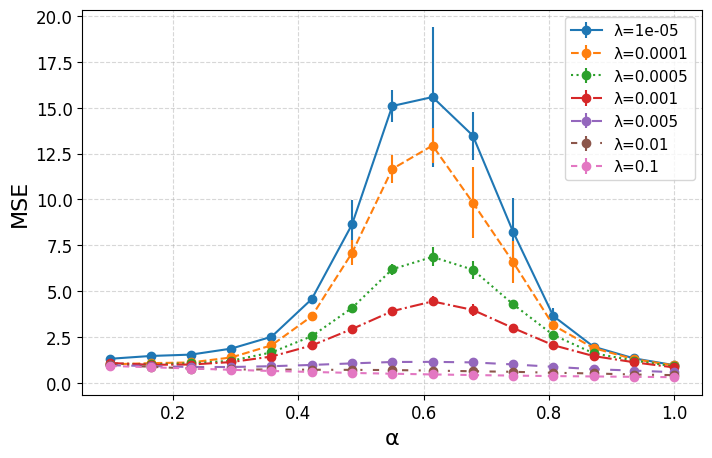

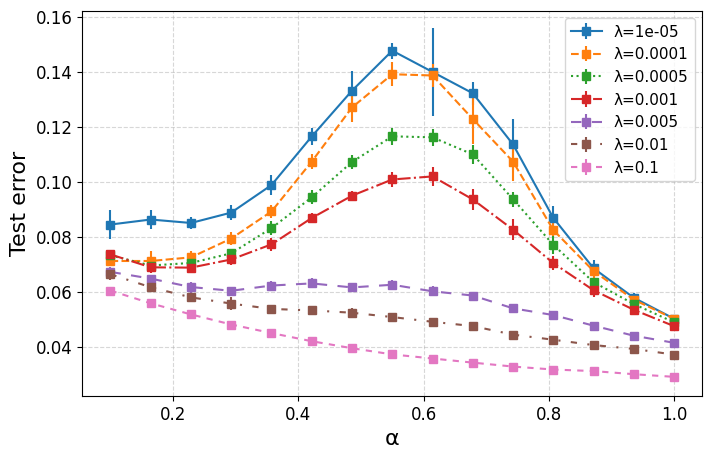

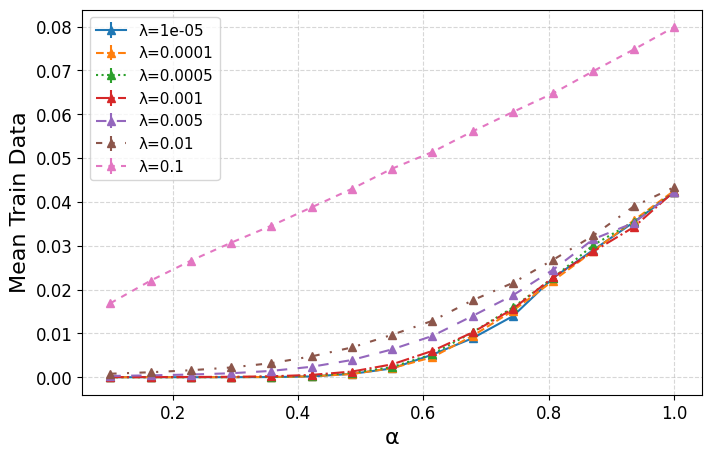

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Path to your local folder ---
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
df = pd.read_csv(base_path, on_bad_lines='warn')
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- Set global font sizes ---
plt.rcParams.update({
    'font.size': 14,          # taille de texte générale
    'axes.labelsize': 16,     # labels des axes
    'axes.titlesize': 18,     # titres des axes
    'legend.fontsize': 11,    # légendes
    'xtick.labelsize': 12,    # ticks x
    'ytick.labelsize': 12     # ticks y
})

linestyles = [
    "-",
    "--",
    ":",
    "-.",
    (0, (5, 5)),
    (0, (3, 5, 1, 5)),
    (0, (3, 3))
]

# --- Plot MSE vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for i, lam in enumerate(sorted(df["lam"].unique())):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["MSE_mean"],
        yerr=subset.get("MSE_std", 0),
        ls=linestyles[i % len(linestyles)], 
        marker='o',
        capsize=0,
        label=f"λ={lam}"
    )
plt.xlabel("α")
plt.ylabel("MSE")
# plt.title(rf"MSE vs α ($\rho$  = {config['rho'][0]})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for i, lam in enumerate(sorted(df["lam"].unique())):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["label_err_mean_noise"],
        yerr=subset.get("label_err_std_noise", 0),
        ls=linestyles[i % len(linestyles)], 
        marker='s',
        capsize=0,
        label=f"λ={lam}"
    )
plt.xlabel("α")
plt.ylabel("Test error")
# plt.title(rf"Label Error vs α ($\rho$  = {config['rho'][0]})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for i, lam in enumerate(sorted(df["lam"].unique())):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(
        subset["alpha"],
        subset["train_data_mean"],
        yerr=subset.get("train_data_std", 0),
        ls=linestyles[i % len(linestyles)], 
        marker='^',
        capsize=0,
        label=f"λ={lam}"
    )
plt.xlabel("α")
plt.ylabel("Mean Train Data")
# plt.title(rf"Train Data vs α ($\rho$ = {config['rho'][0]})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Eigenvalue distributions per $\rho$

Found 15 W_Q files and 15 W_K files.

Processing Q matrices: W_Q_runs_0.pkl


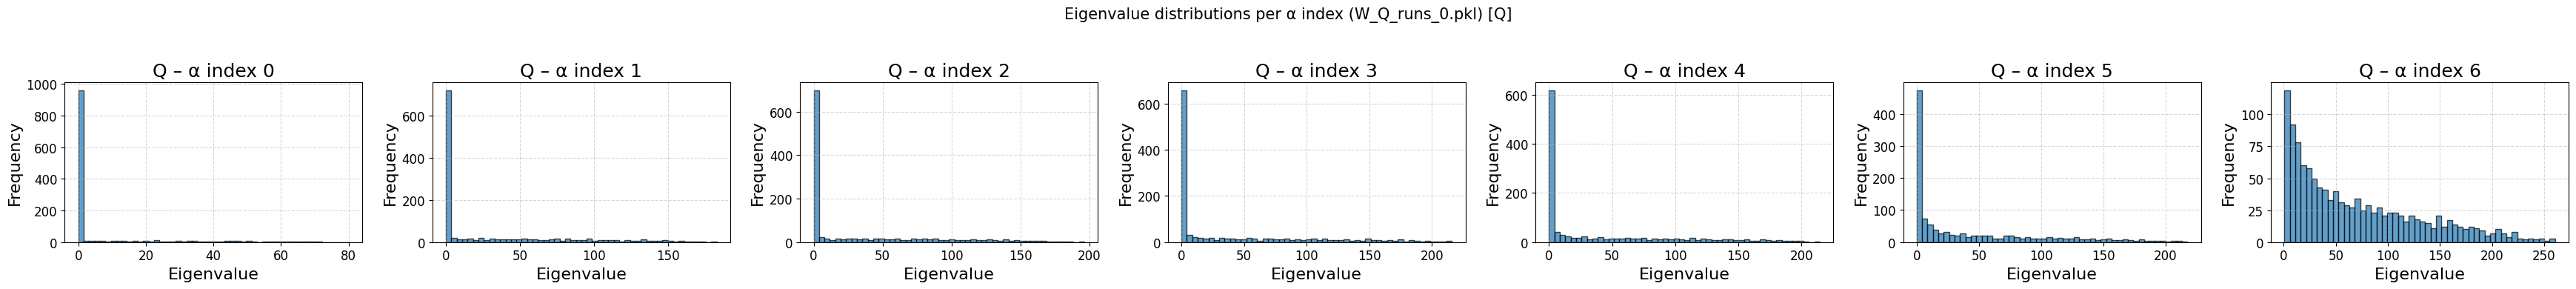


Processing Q matrices: W_Q_runs_1.pkl


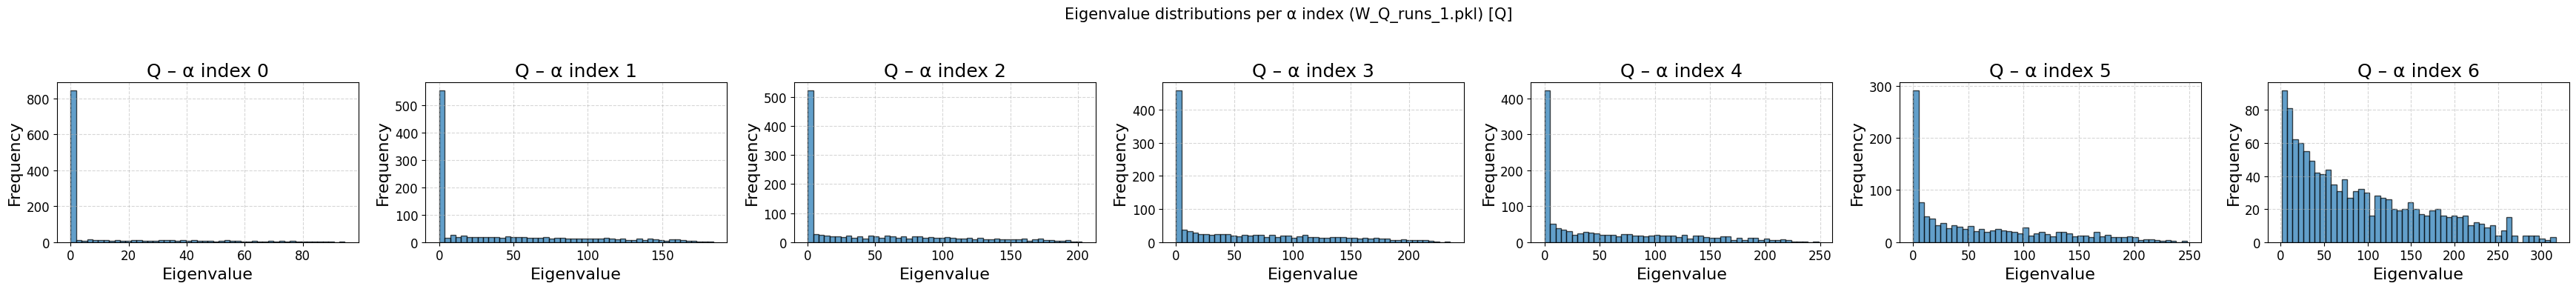


Processing Q matrices: W_Q_runs_10.pkl


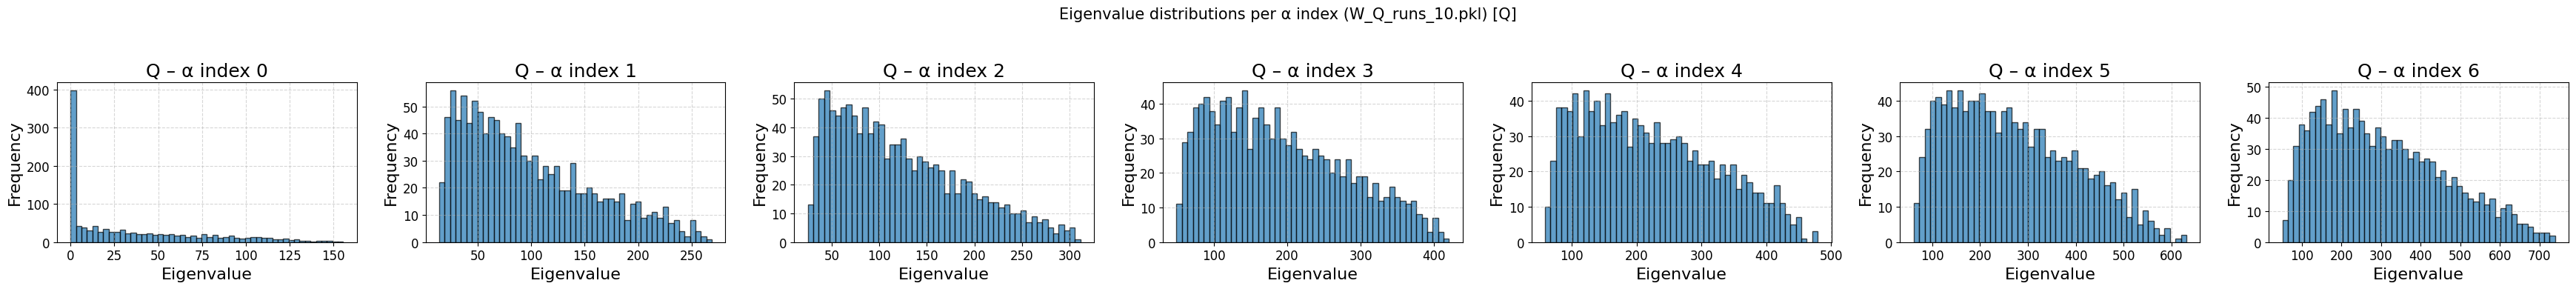


Processing Q matrices: W_Q_runs_11.pkl


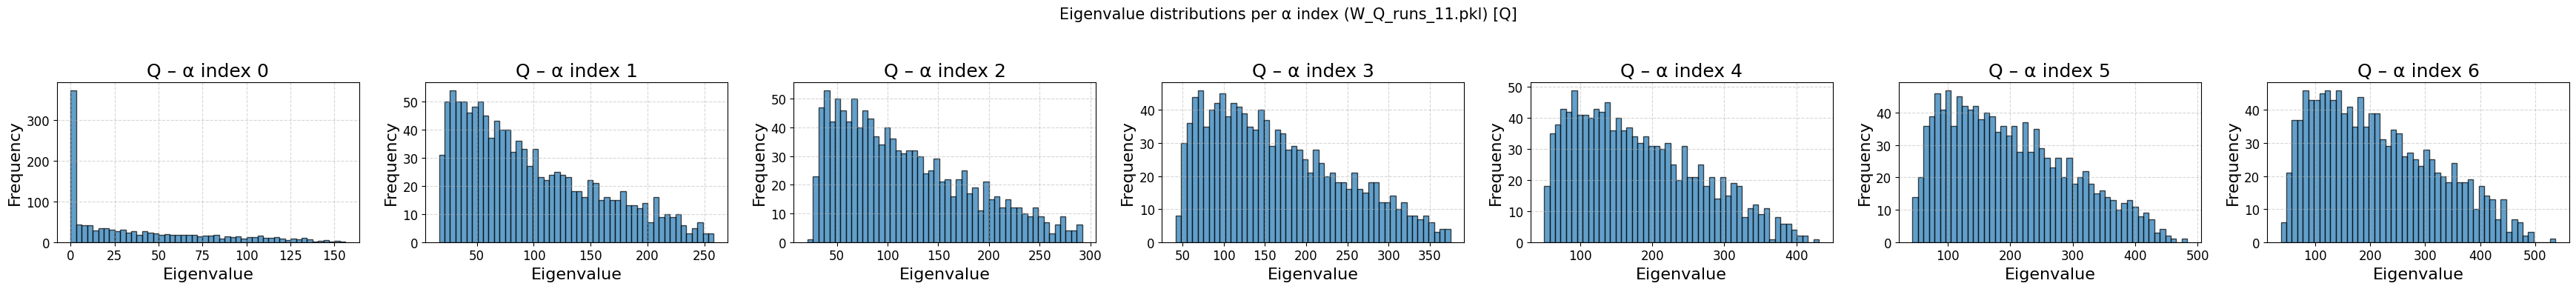


Processing Q matrices: W_Q_runs_12.pkl


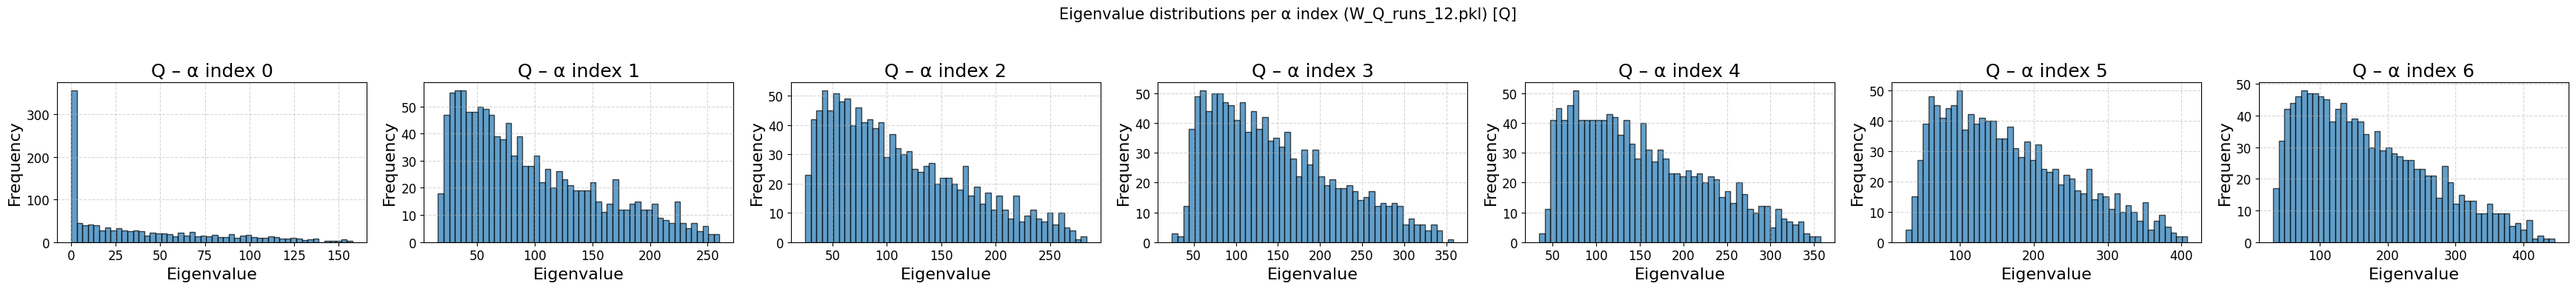


Processing Q matrices: W_Q_runs_13.pkl


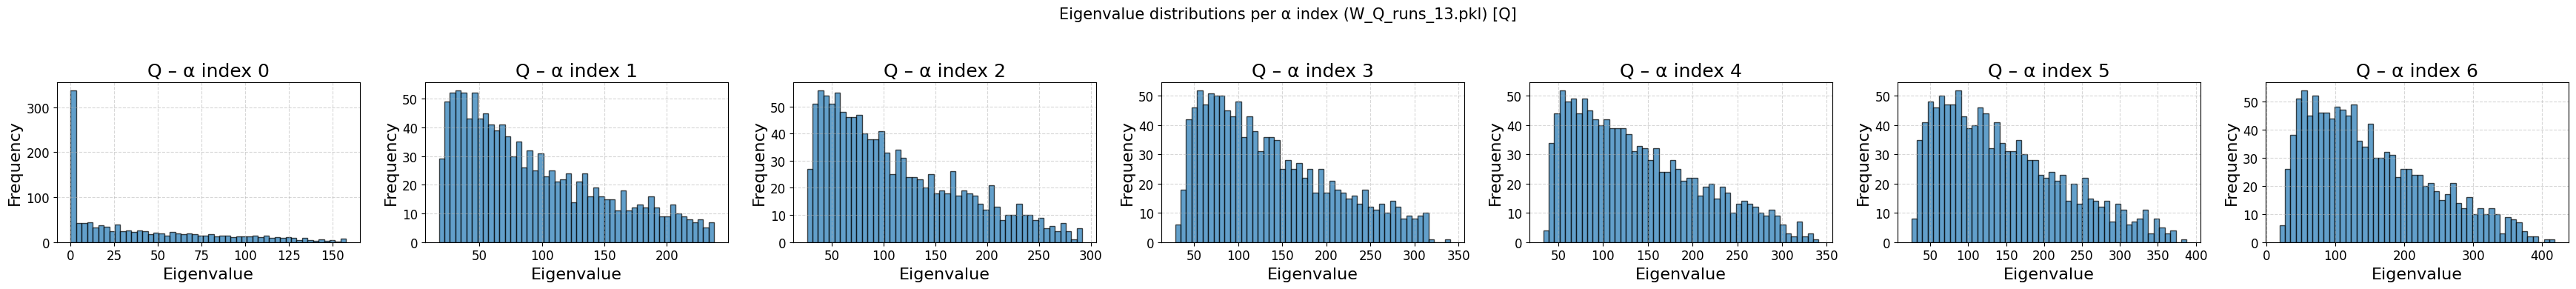


Processing Q matrices: W_Q_runs_14.pkl


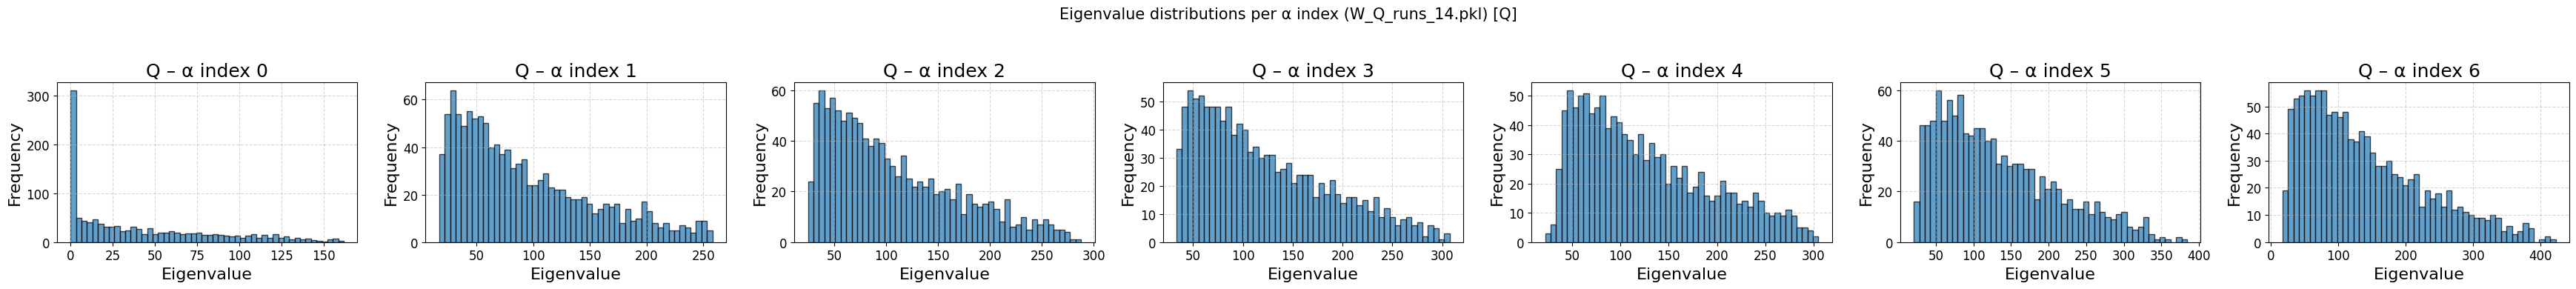


Processing Q matrices: W_Q_runs_2.pkl


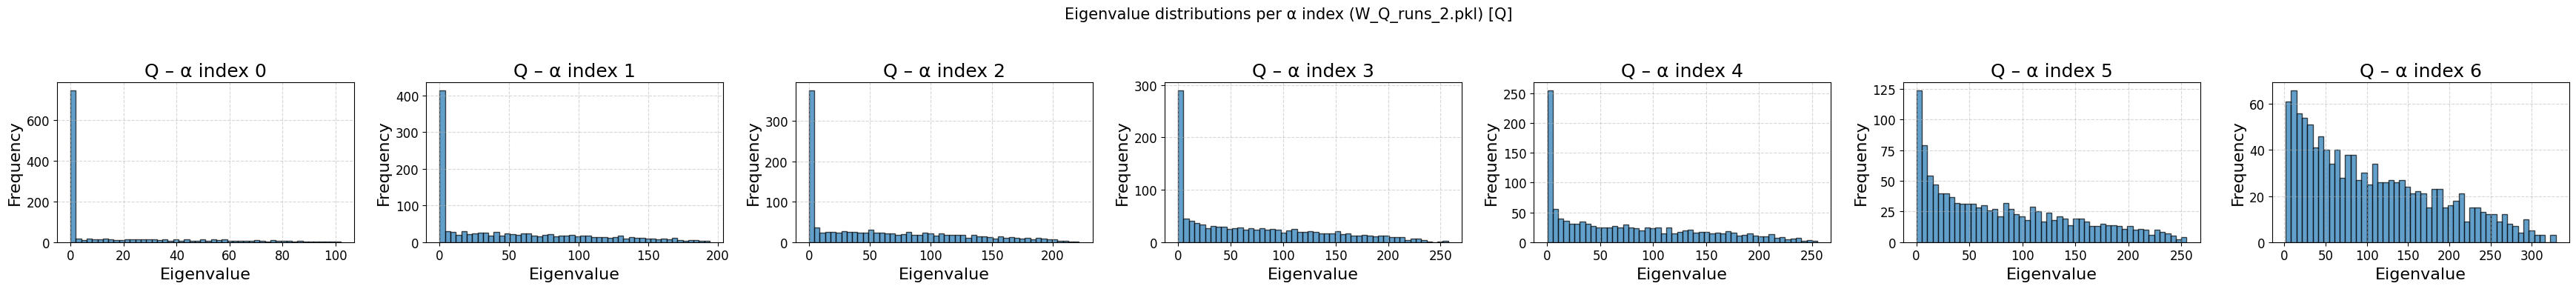


Processing Q matrices: W_Q_runs_3.pkl


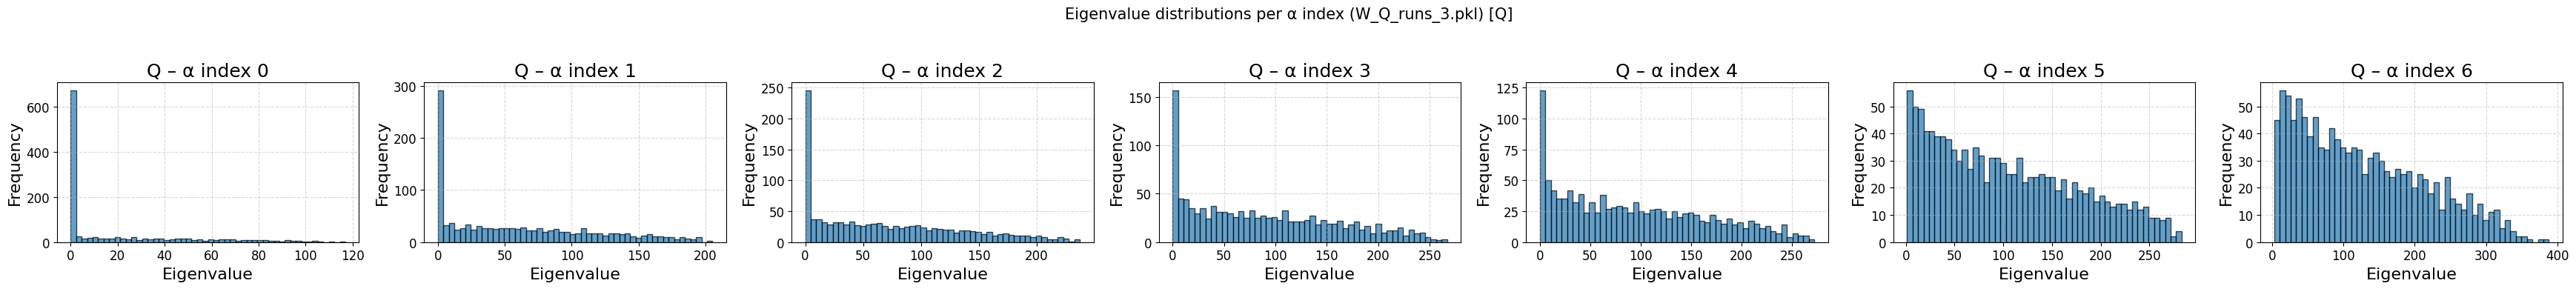


Processing Q matrices: W_Q_runs_4.pkl


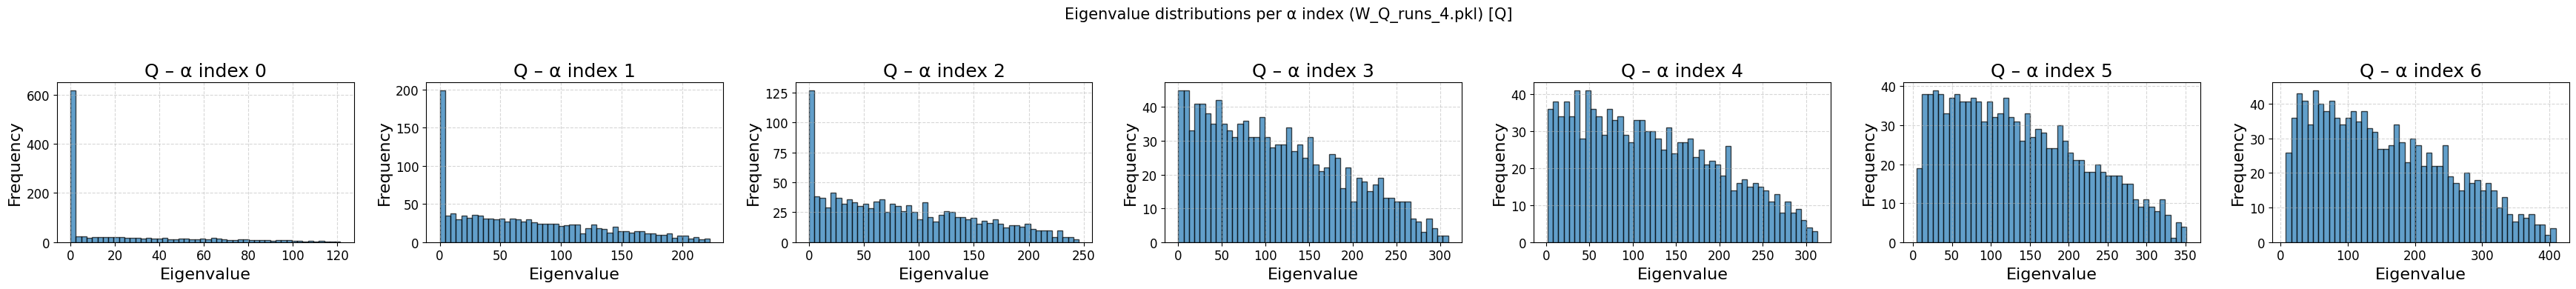


Processing Q matrices: W_Q_runs_5.pkl


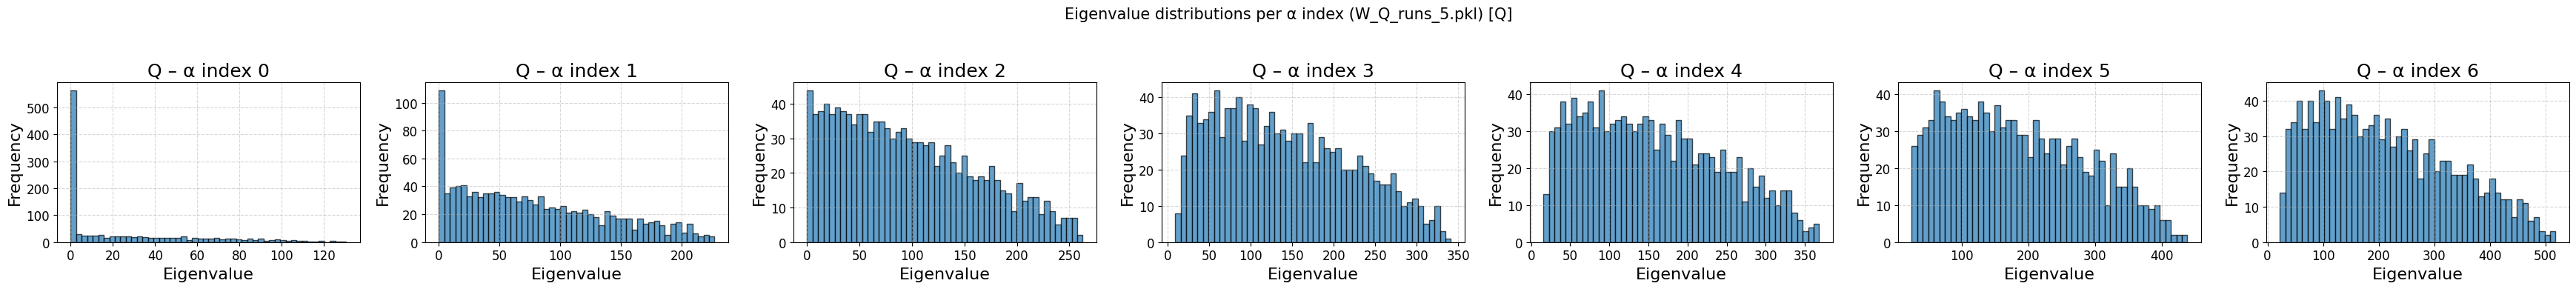


Processing Q matrices: W_Q_runs_6.pkl


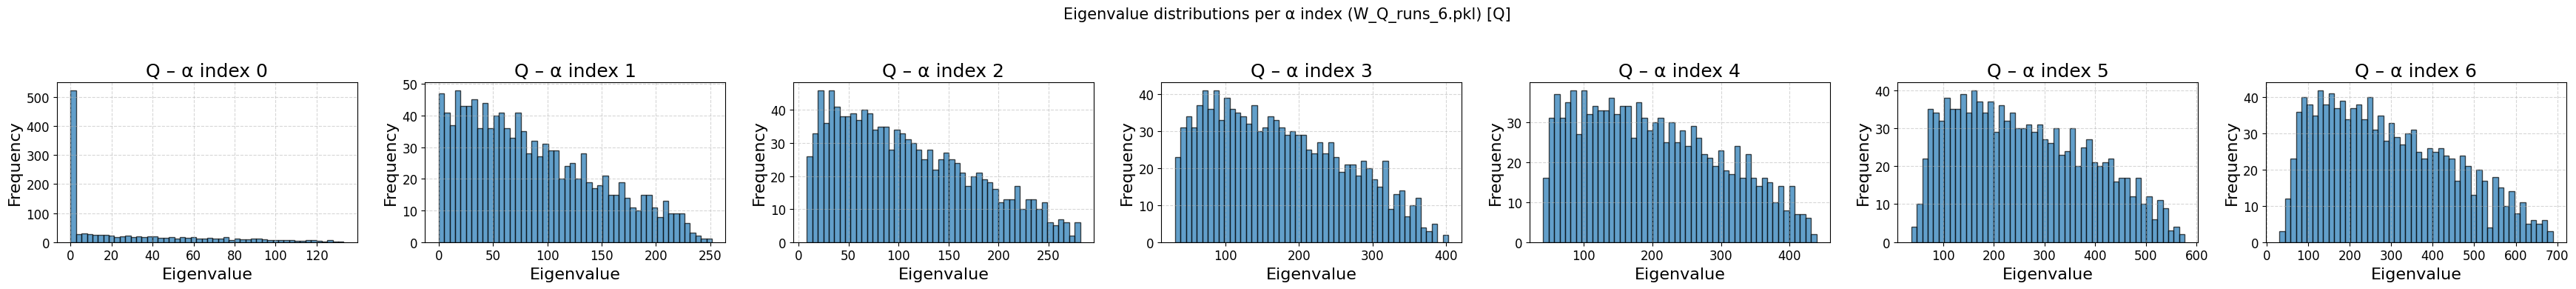


Processing Q matrices: W_Q_runs_7.pkl


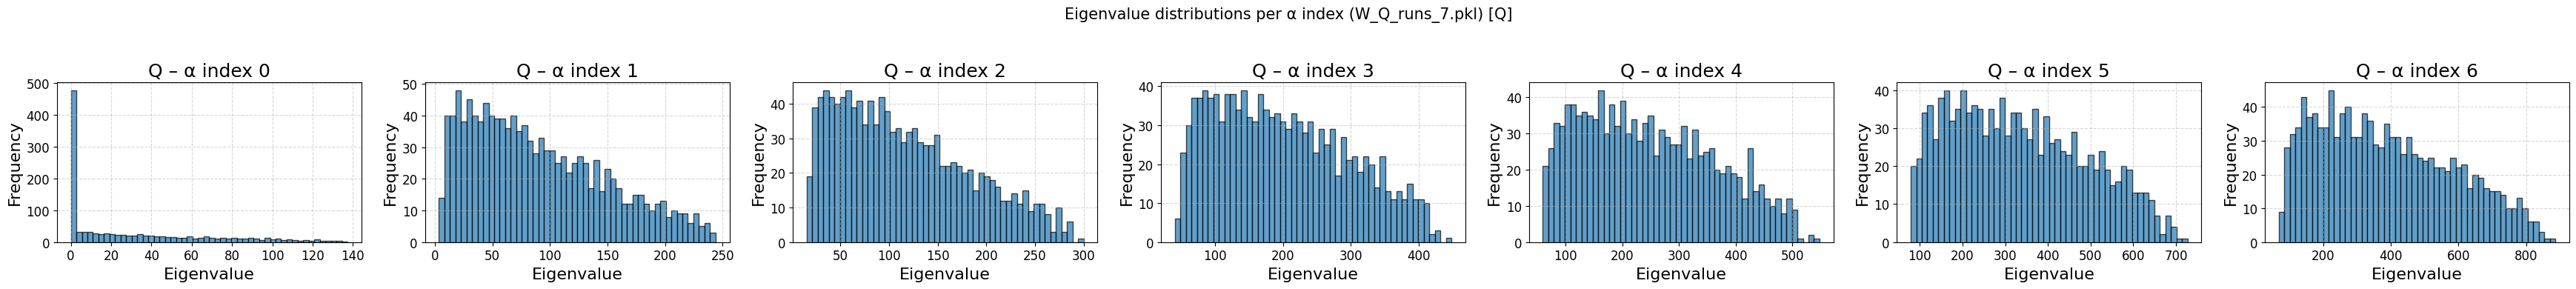


Processing Q matrices: W_Q_runs_8.pkl


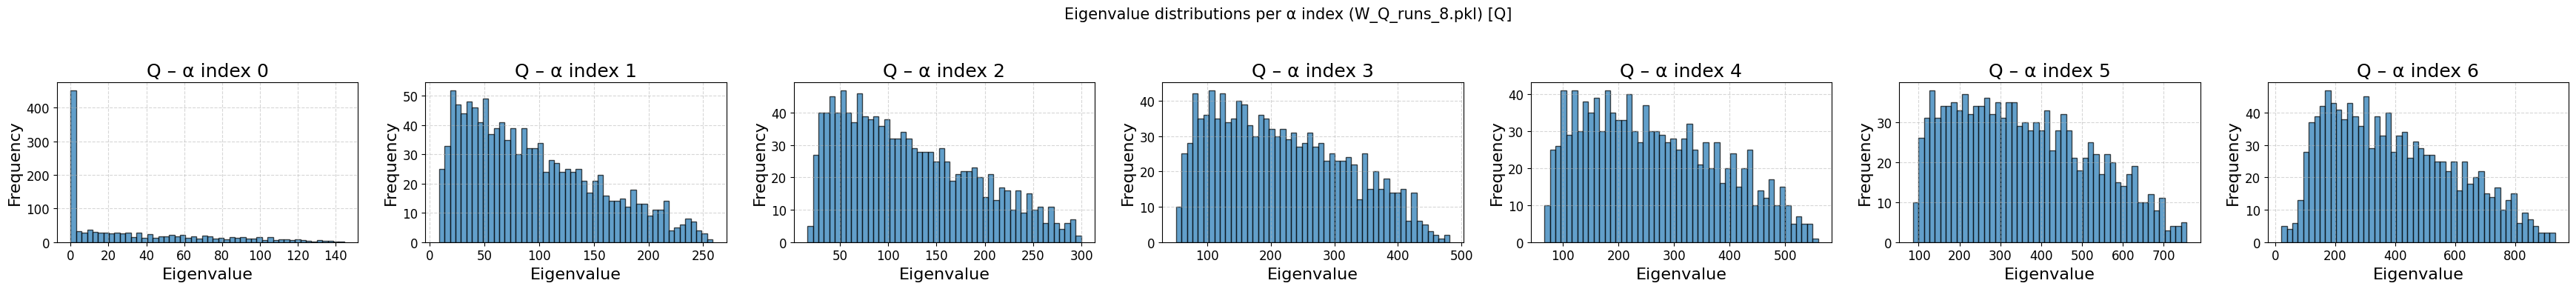


Processing Q matrices: W_Q_runs_9.pkl


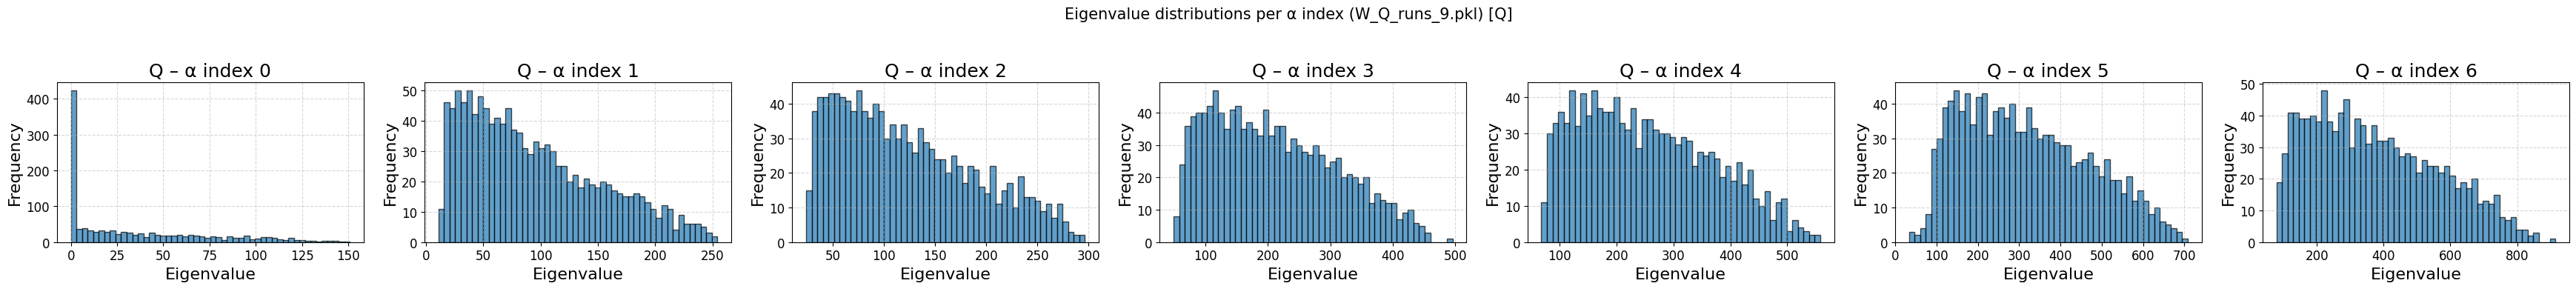


Processing K matrices: W_K_runs_0.pkl


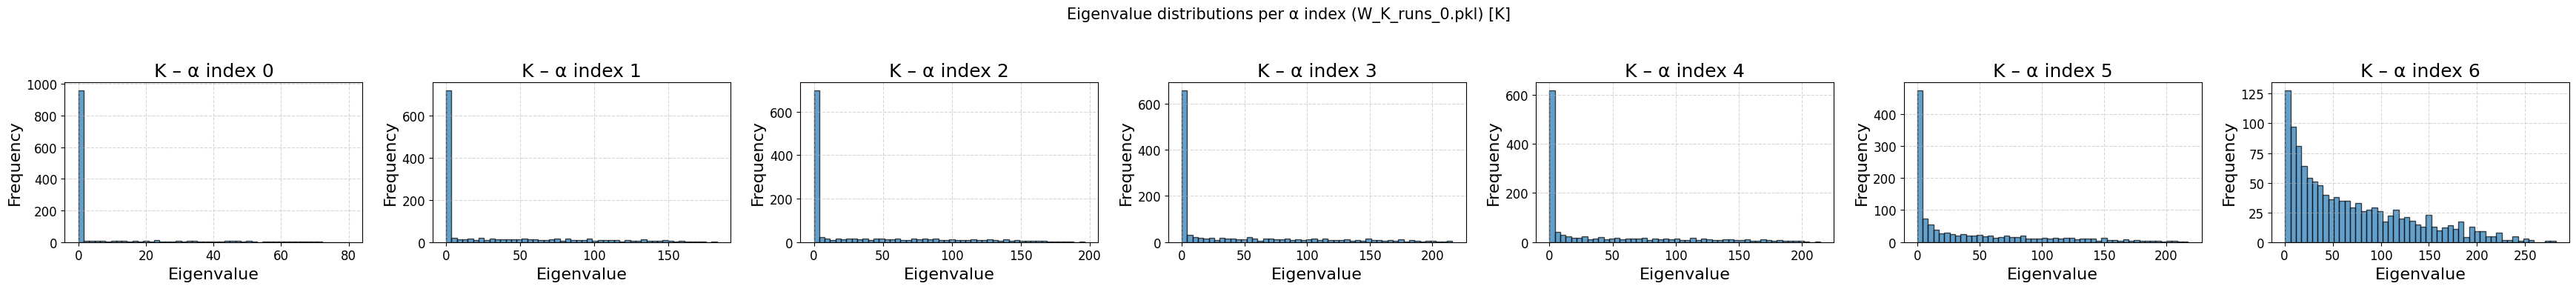


Processing K matrices: W_K_runs_1.pkl


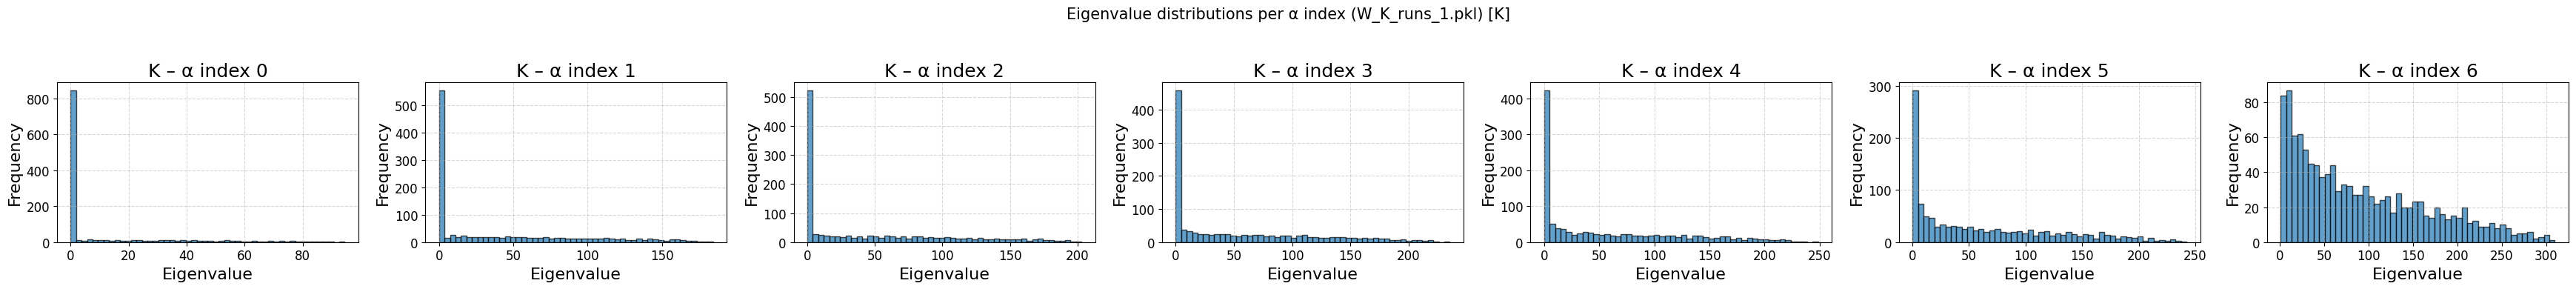


Processing K matrices: W_K_runs_10.pkl


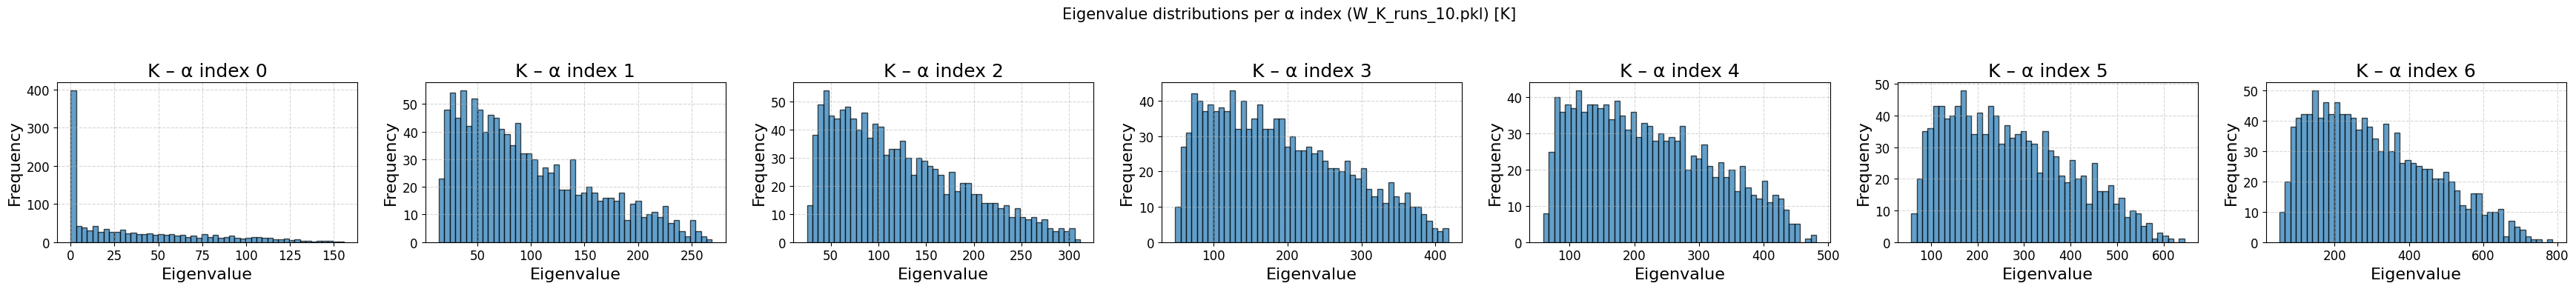


Processing K matrices: W_K_runs_11.pkl


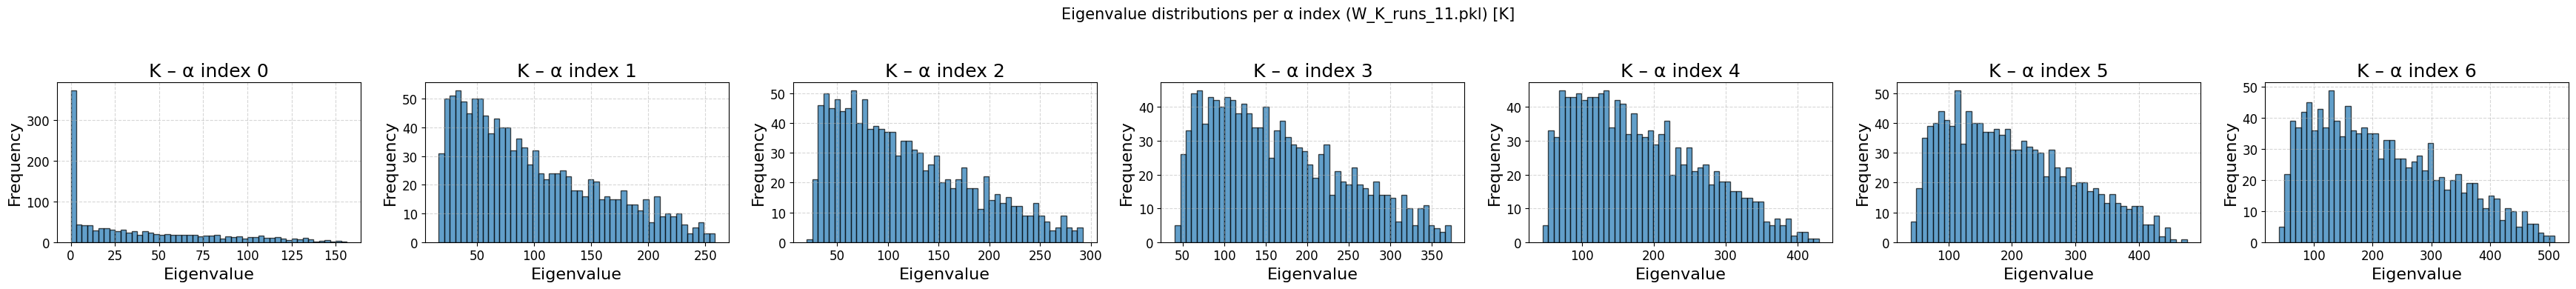


Processing K matrices: W_K_runs_12.pkl


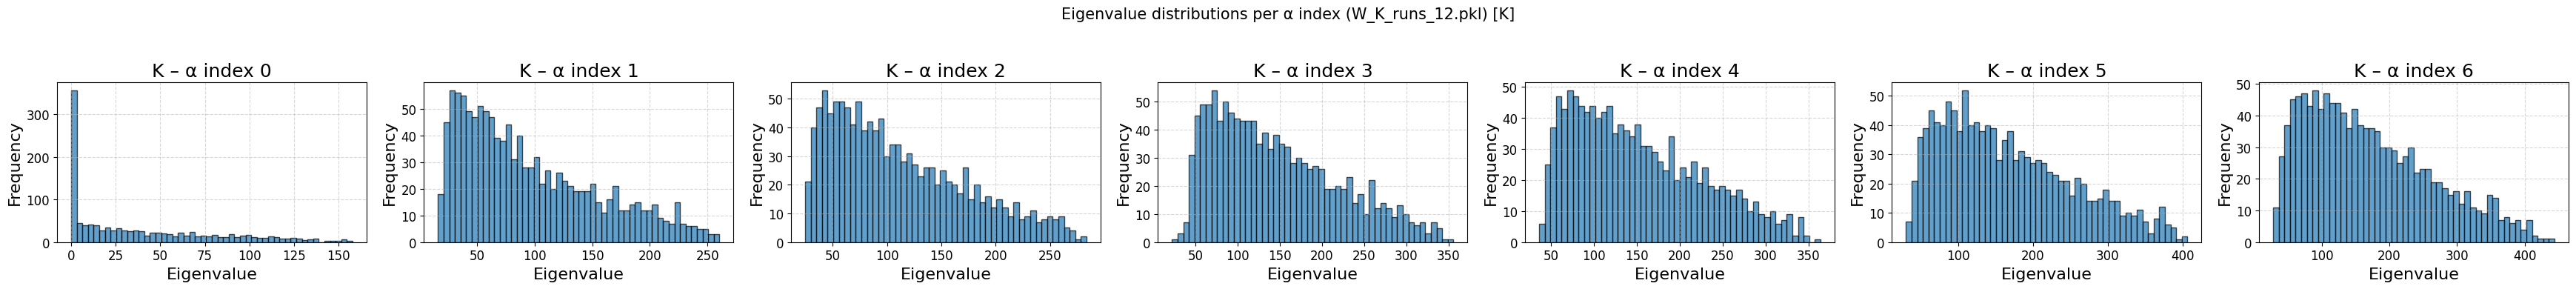


Processing K matrices: W_K_runs_13.pkl


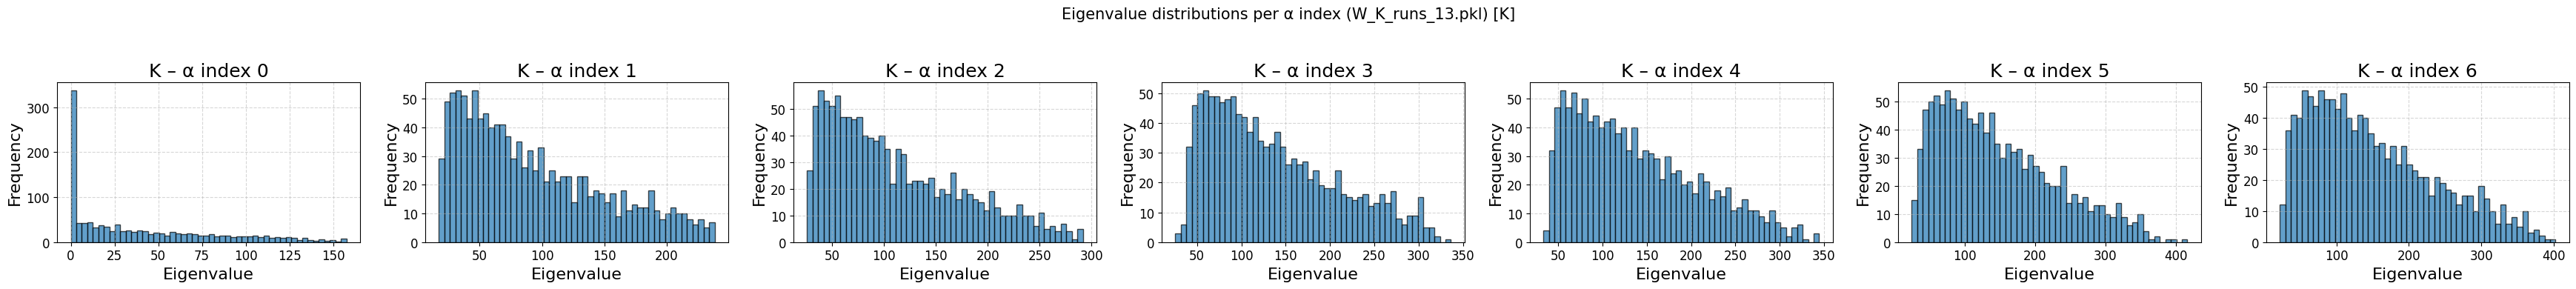


Processing K matrices: W_K_runs_14.pkl


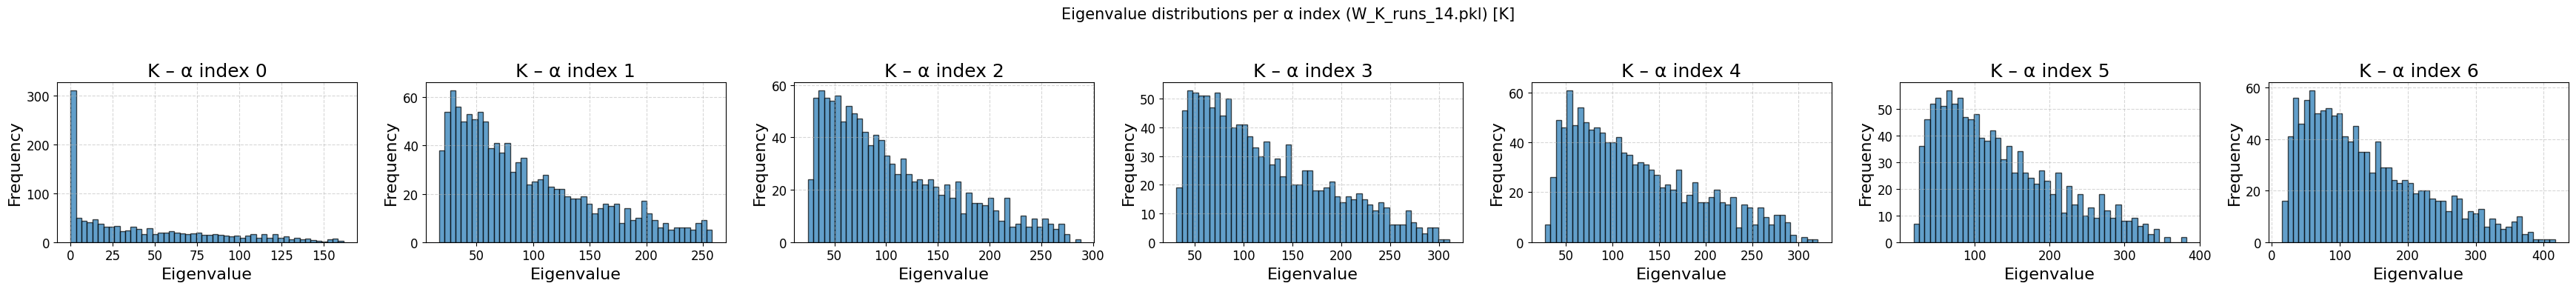


Processing K matrices: W_K_runs_2.pkl


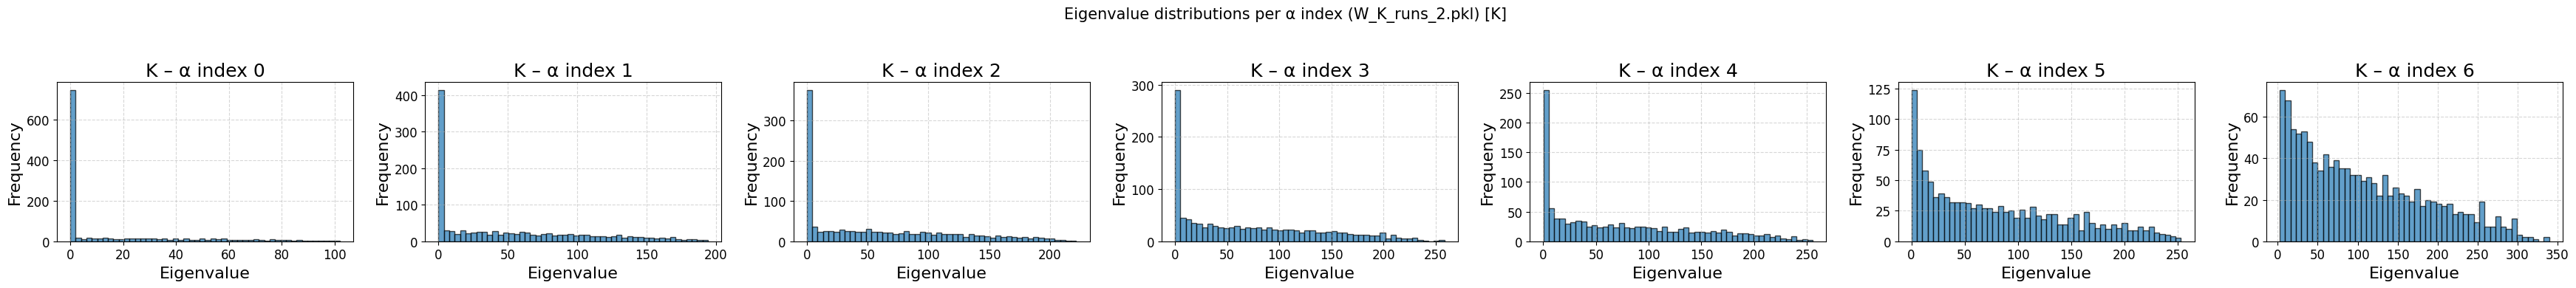


Processing K matrices: W_K_runs_3.pkl


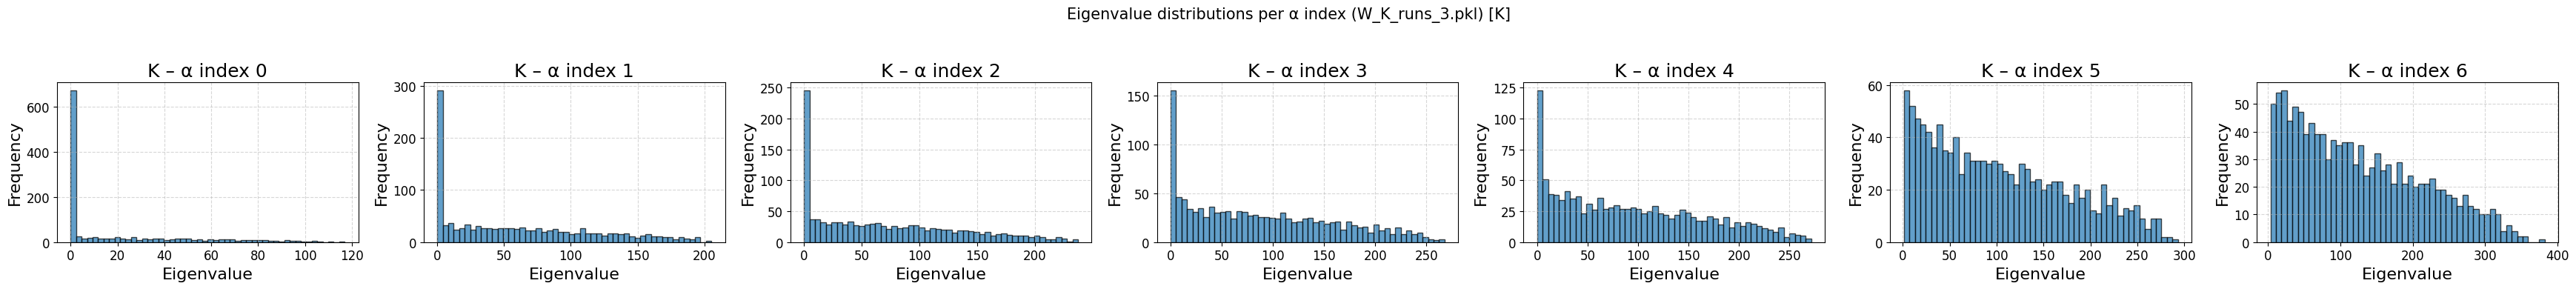


Processing K matrices: W_K_runs_4.pkl


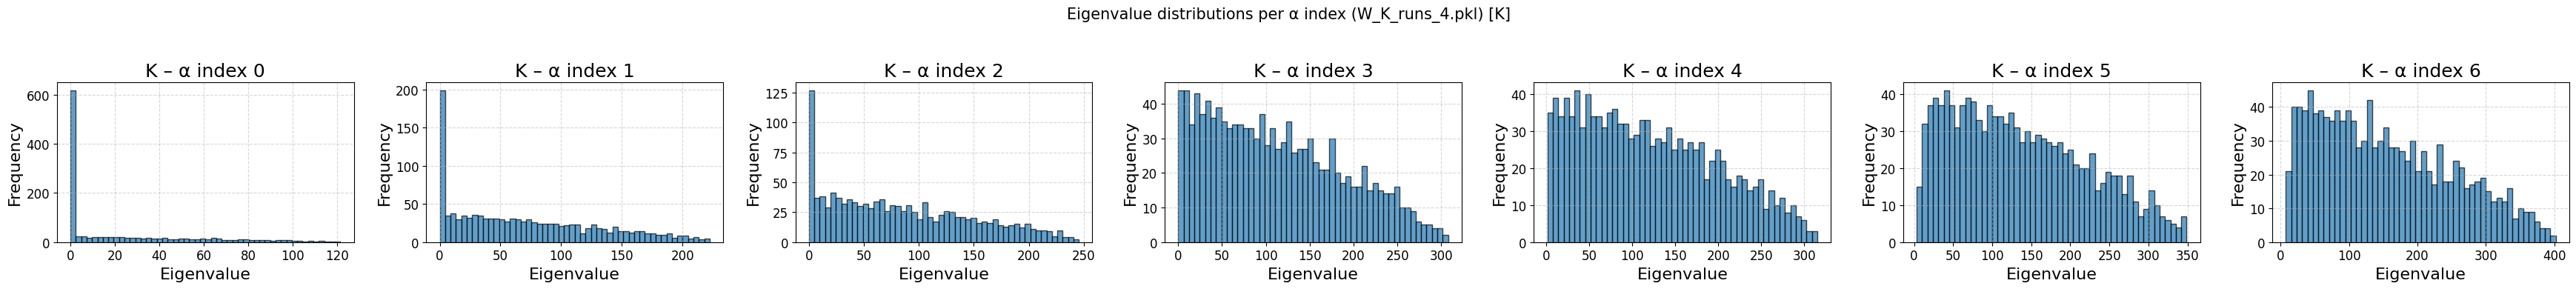


Processing K matrices: W_K_runs_5.pkl


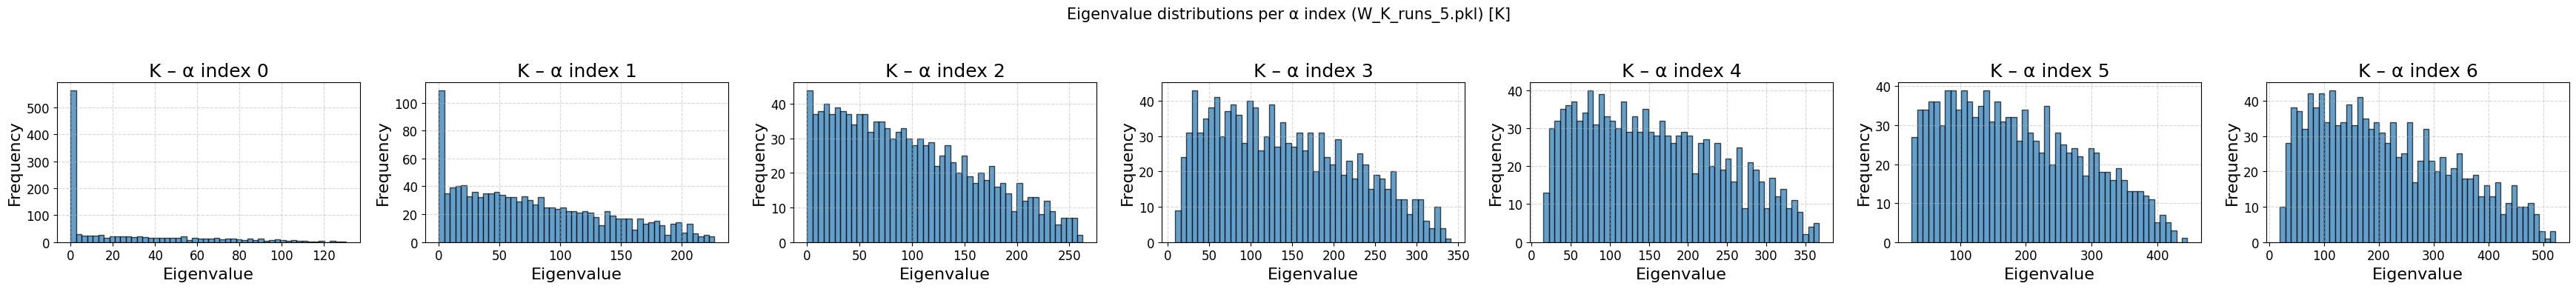


Processing K matrices: W_K_runs_6.pkl


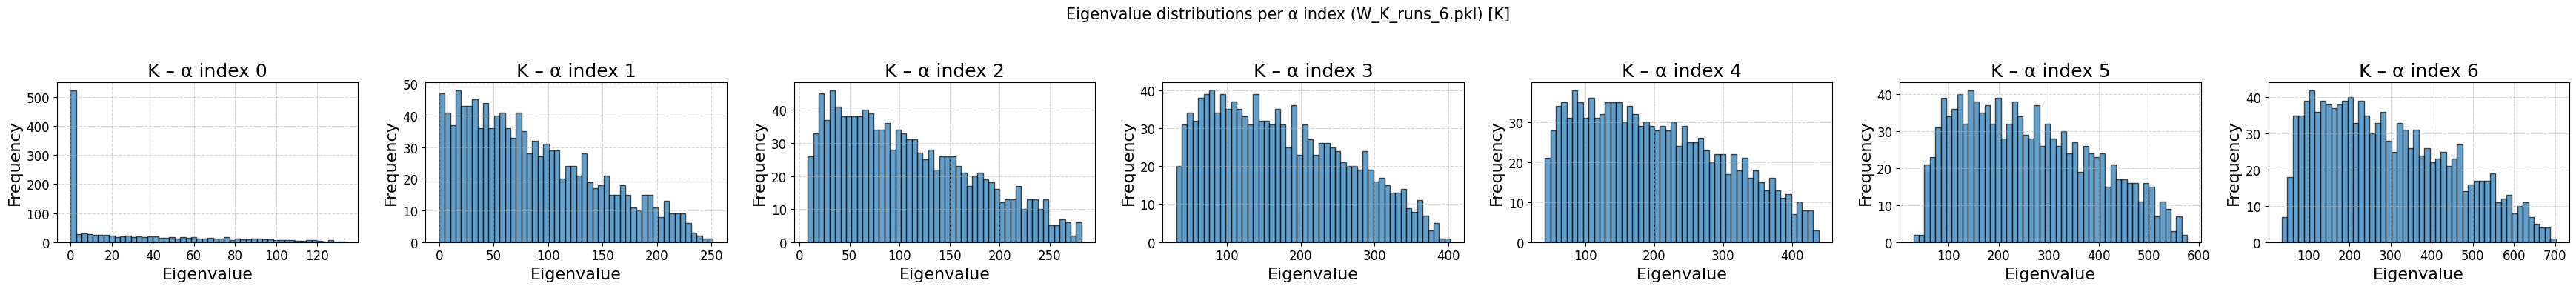


Processing K matrices: W_K_runs_7.pkl


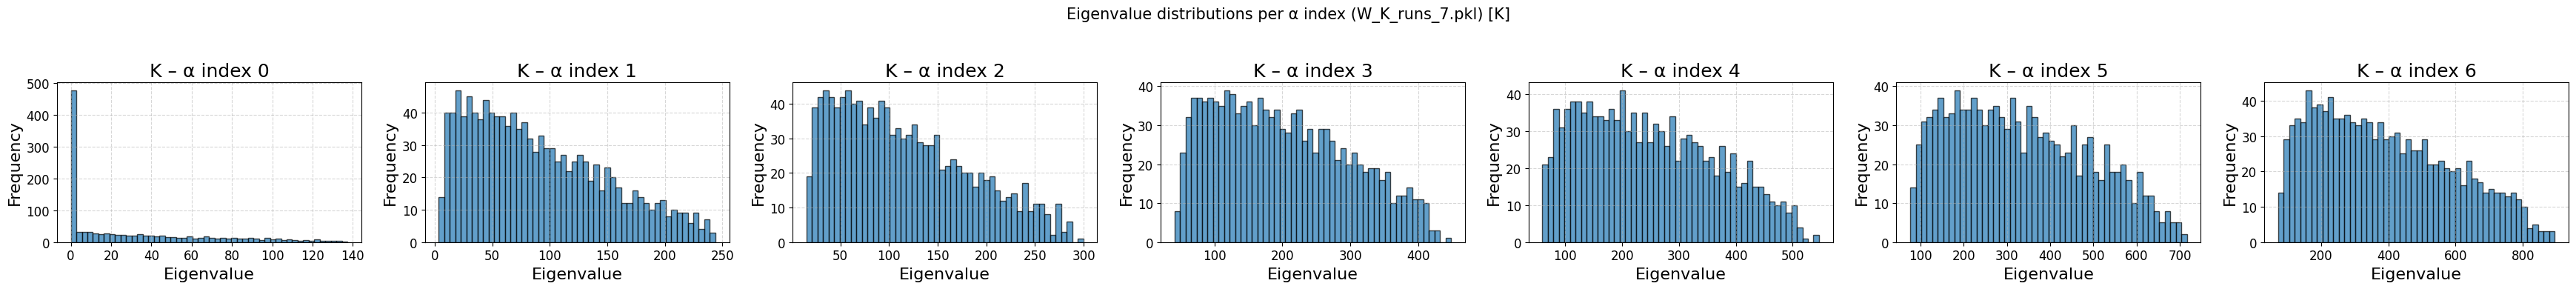


Processing K matrices: W_K_runs_8.pkl


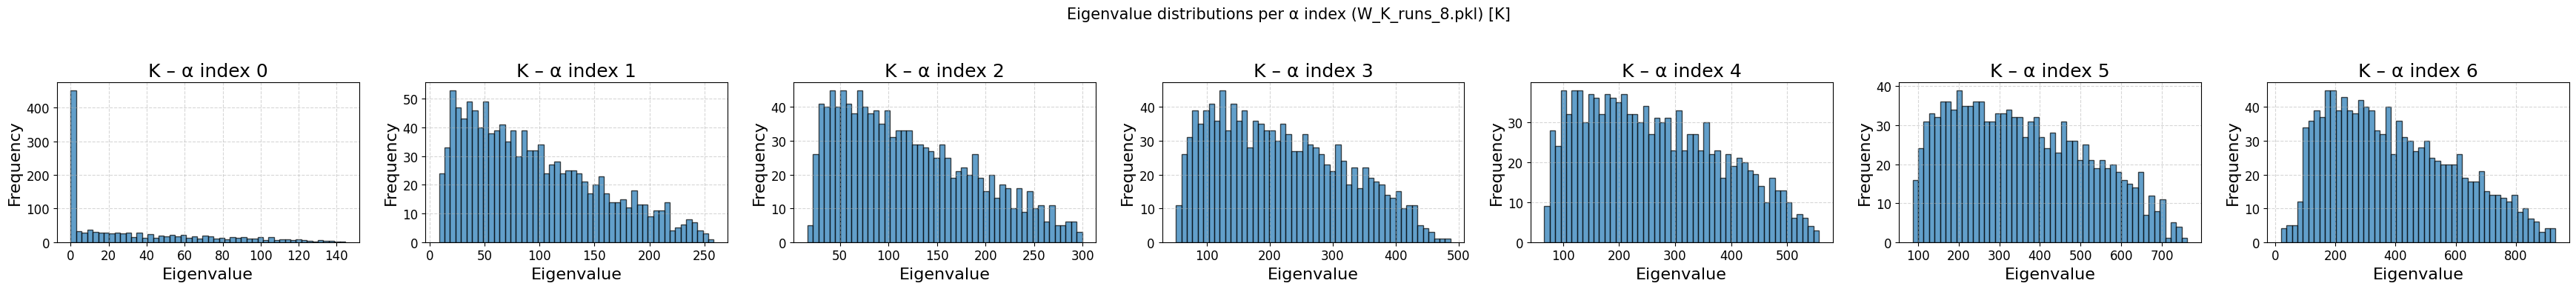


Processing K matrices: W_K_runs_9.pkl


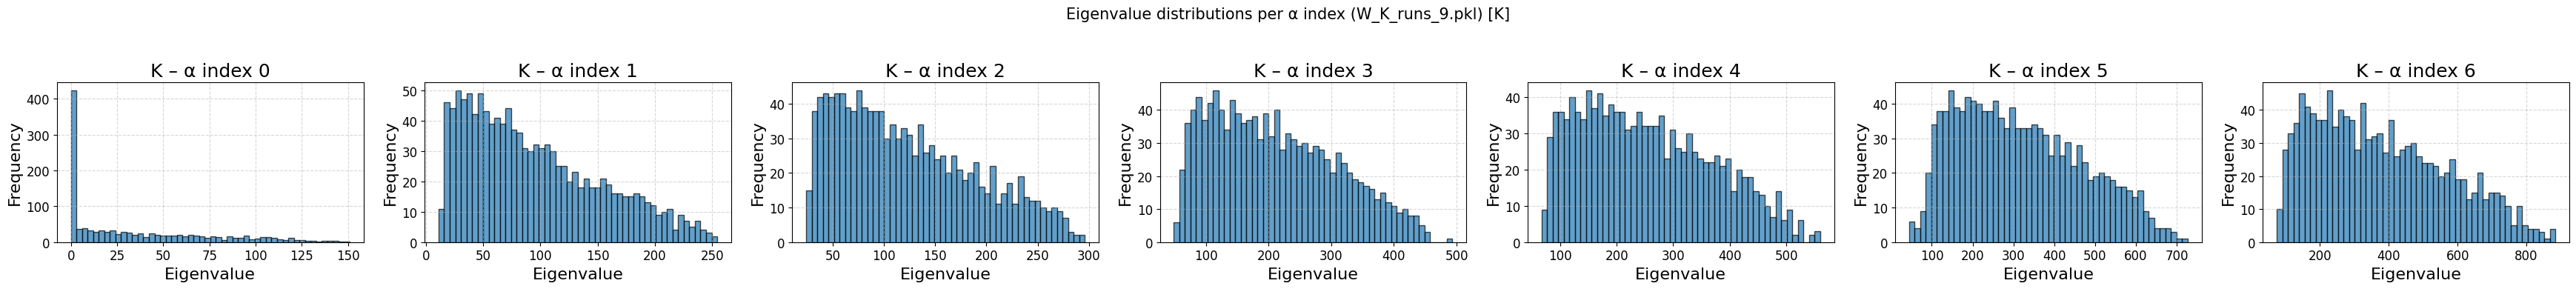

In [16]:
# --- Path to your results directory ---
run_dir = f"../results/run_{run_id}"  # replace with your run_id

# --- Find all pickle files ---
pkl_Q_files = sorted(glob.glob(os.path.join(run_dir, "W_Q_runs_*.pkl")))
pkl_K_files = sorted(glob.glob(os.path.join(run_dir, "W_K_runs_*.pkl")))

print(f"Found {len(pkl_Q_files)} W_Q files and {len(pkl_K_files)} W_K files.")

# --- Helper function to plot a given W_* file ---
def plot_W_spectra(pkl_file, label_type="Q"):
    with open(pkl_file, "rb") as f:
        W_runs_all = pickle.load(f)  # List of W lists per α index

    num_alpha = len(W_runs_all)
    fig, axes = plt.subplots(1, num_alpha, figsize=(5*num_alpha, 4), squeeze=False)

    for i, W_list in enumerate(W_runs_all):
        all_eigvals_i = []
        for W in W_list:
            eigvals = np.linalg.eigvalsh(W @ W.T)
            all_eigvals_i.extend(eigvals)

        all_eigvals_i = np.array(all_eigvals_i)
        ax = axes[0, i]
        ax.hist(all_eigvals_i, bins=50, alpha=0.7, edgecolor='black')
        ax.set_xlabel("Eigenvalue")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{label_type} – α index {i}")
        ax.grid(True, linestyle="--", alpha=0.5)

    fig.suptitle(f"Eigenvalue distributions per α index ({os.path.basename(pkl_file)}) [{label_type}]", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --- Plot all W_Q_runs_*.pkl files ---
for pkl_file in pkl_Q_files:
    print(f"\nProcessing Q matrices: {os.path.basename(pkl_file)}")
    plot_W_spectra(pkl_file, label_type="Q")

# --- Plot all W_K_runs_*.pkl files ---
for pkl_file in pkl_K_files:
    print(f"\nProcessing K matrices: {os.path.basename(pkl_file)}")
    plot_W_spectra(pkl_file, label_type="K")


Comparing Q vs K for W_Q_runs_0.pkl


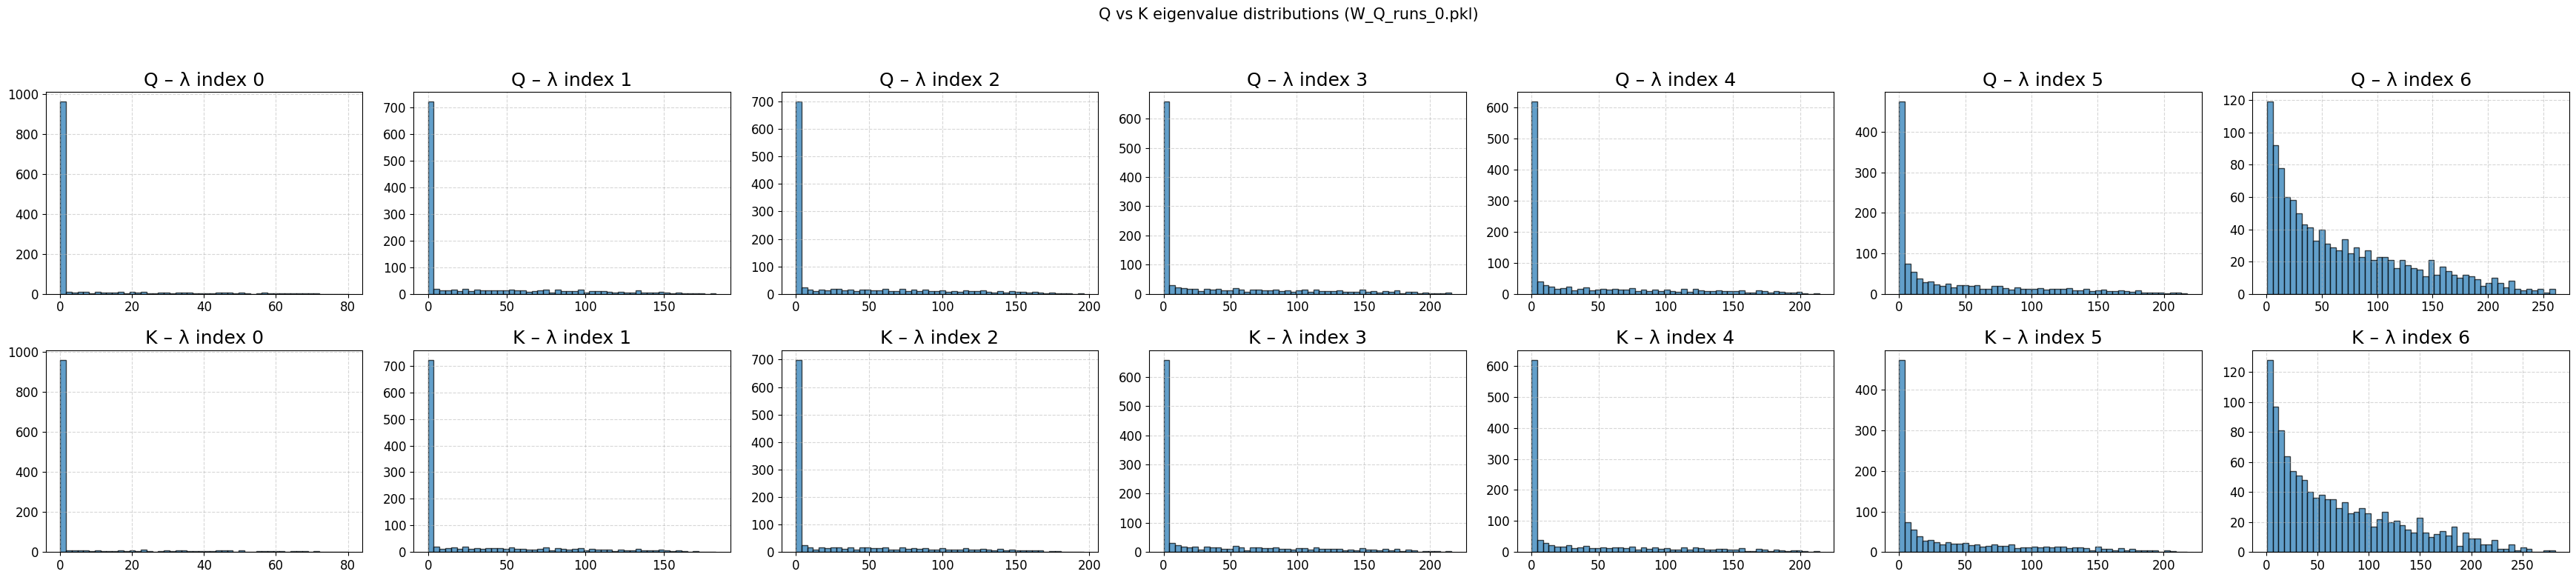


Comparing Q vs K for W_Q_runs_1.pkl


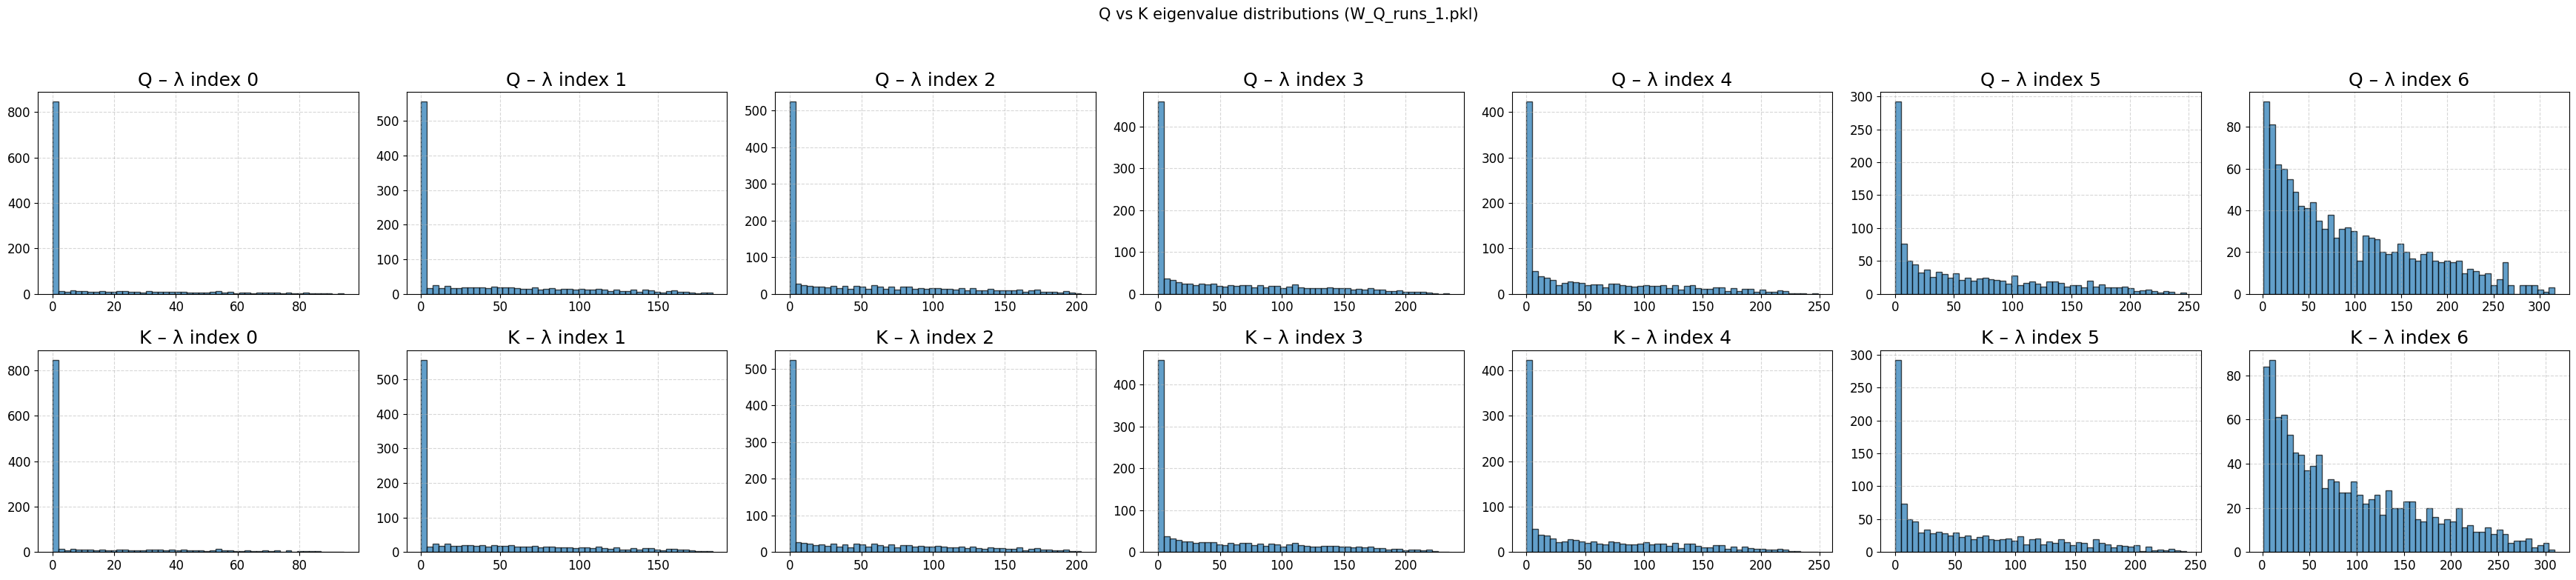


Comparing Q vs K for W_Q_runs_10.pkl


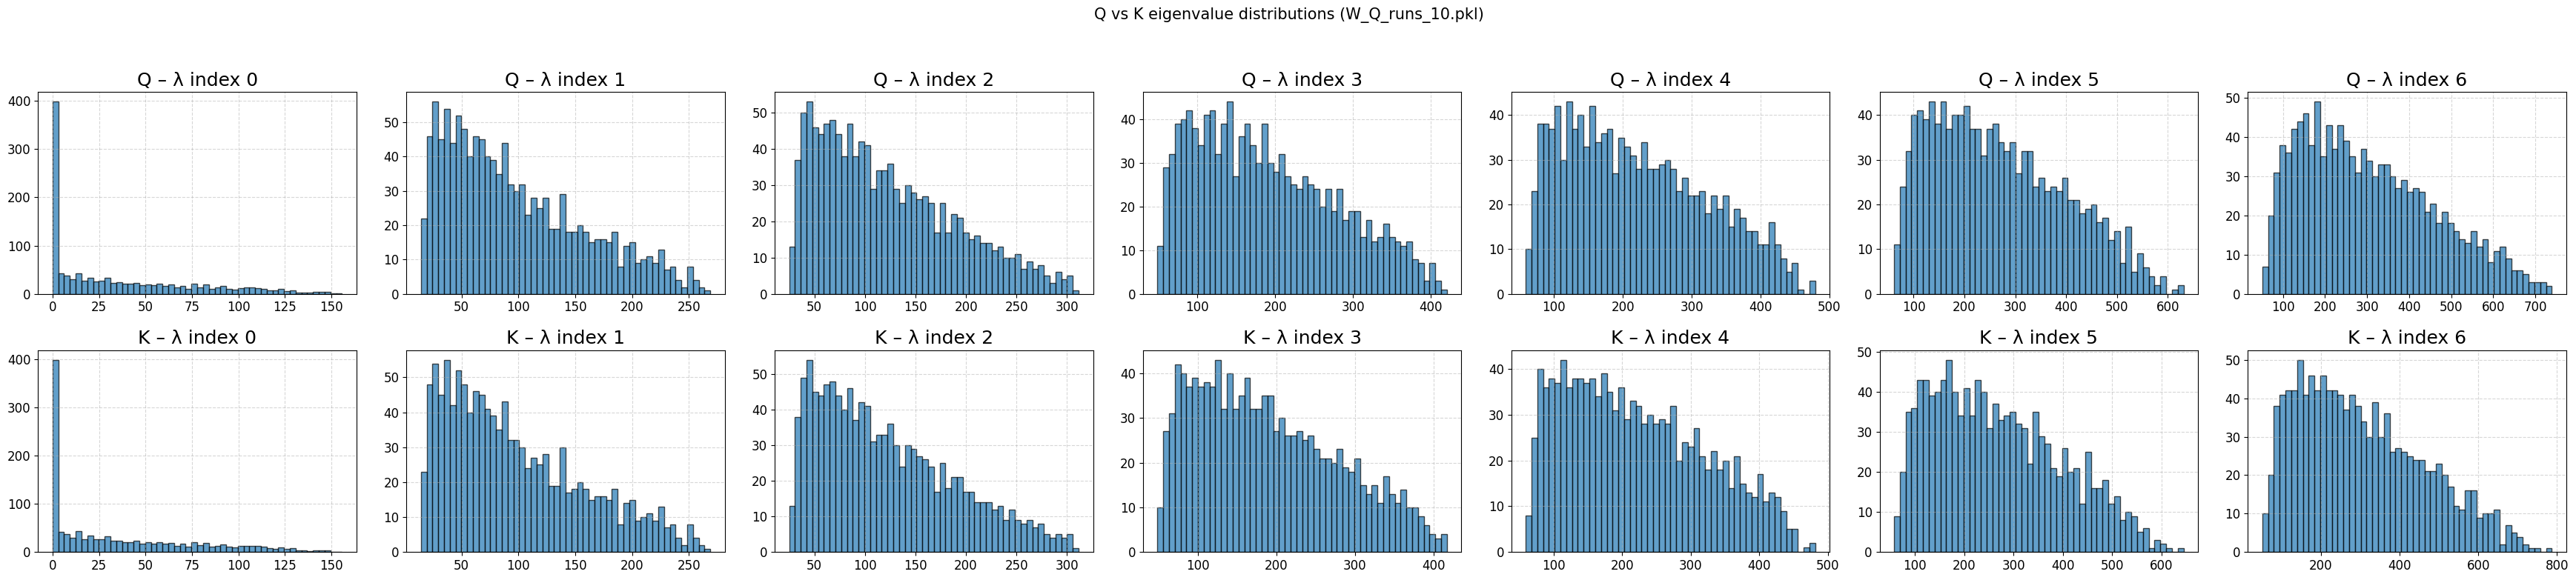


Comparing Q vs K for W_Q_runs_11.pkl


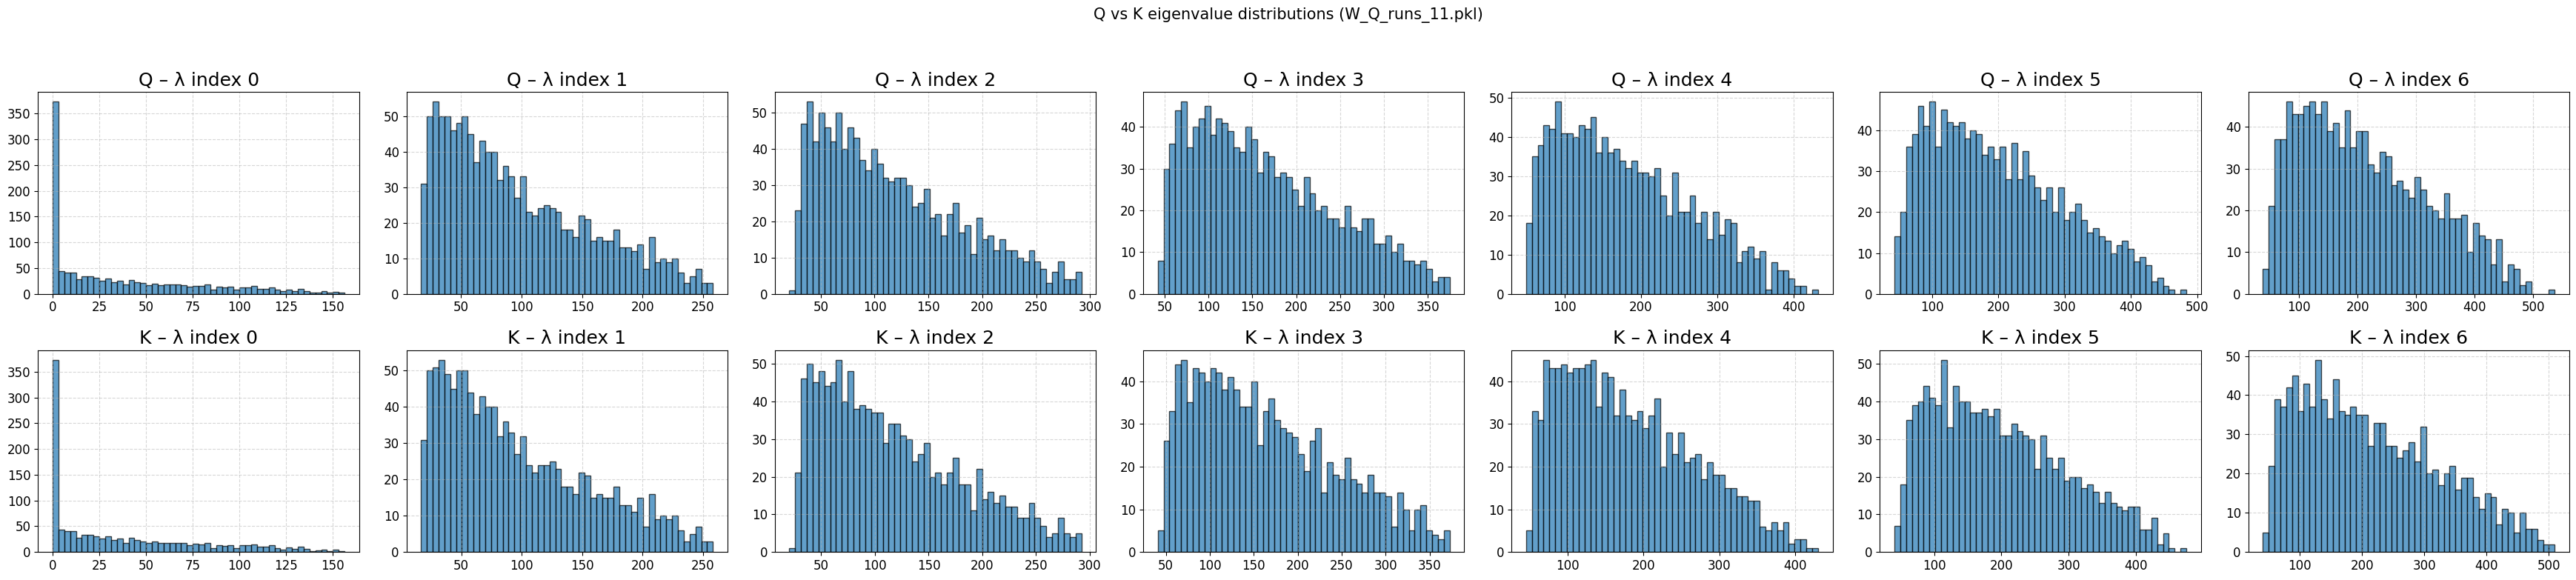


Comparing Q vs K for W_Q_runs_12.pkl


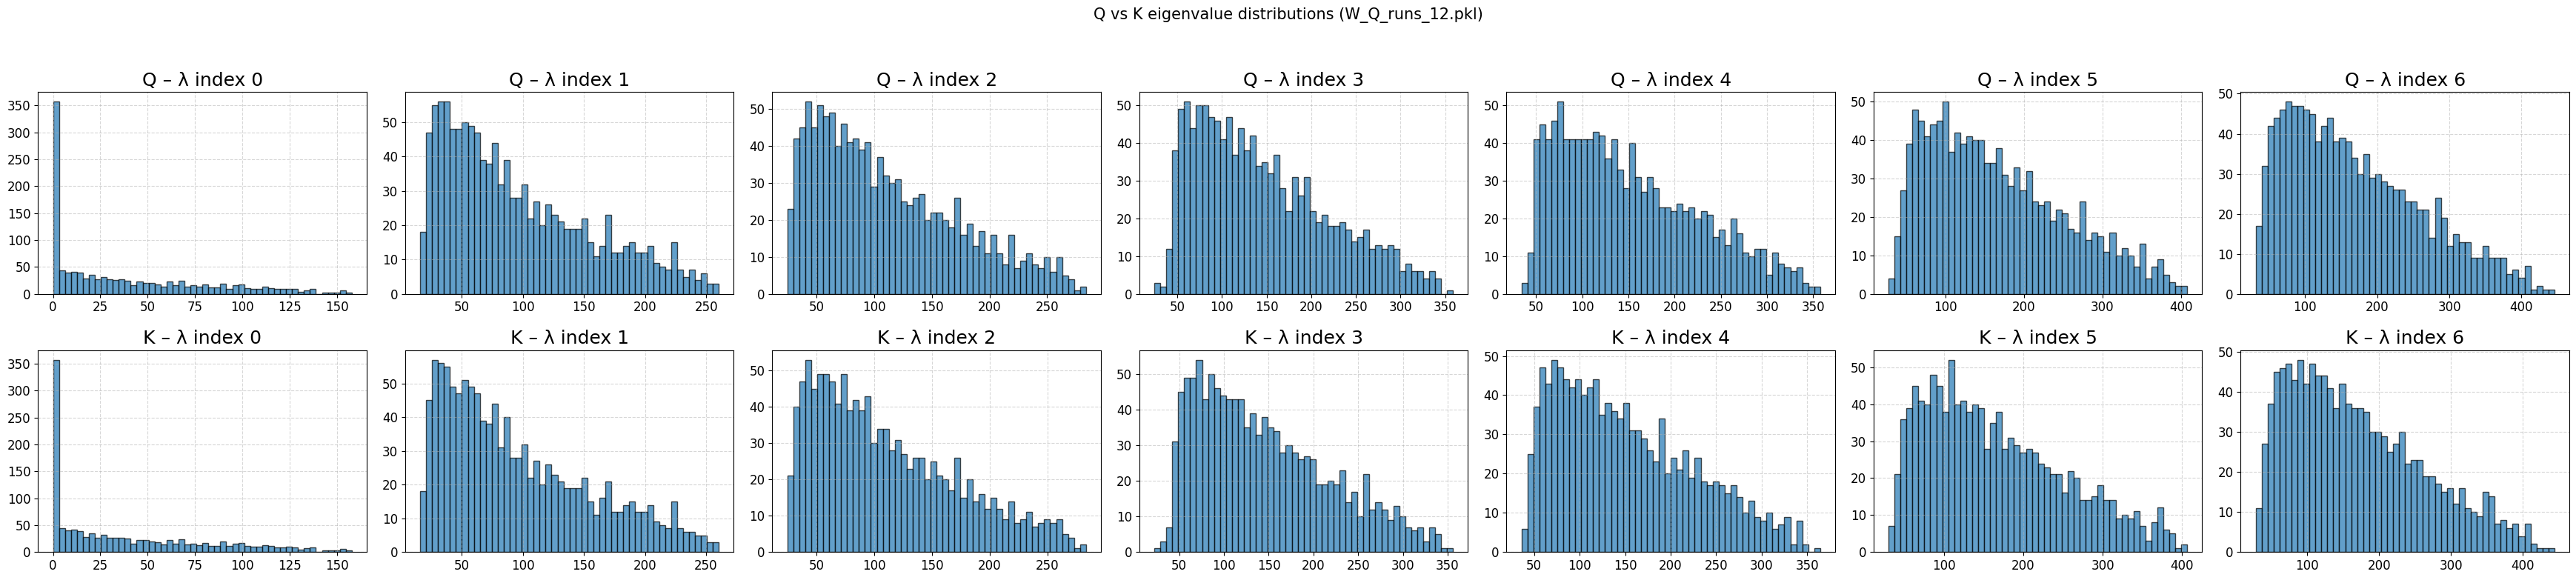


Comparing Q vs K for W_Q_runs_13.pkl


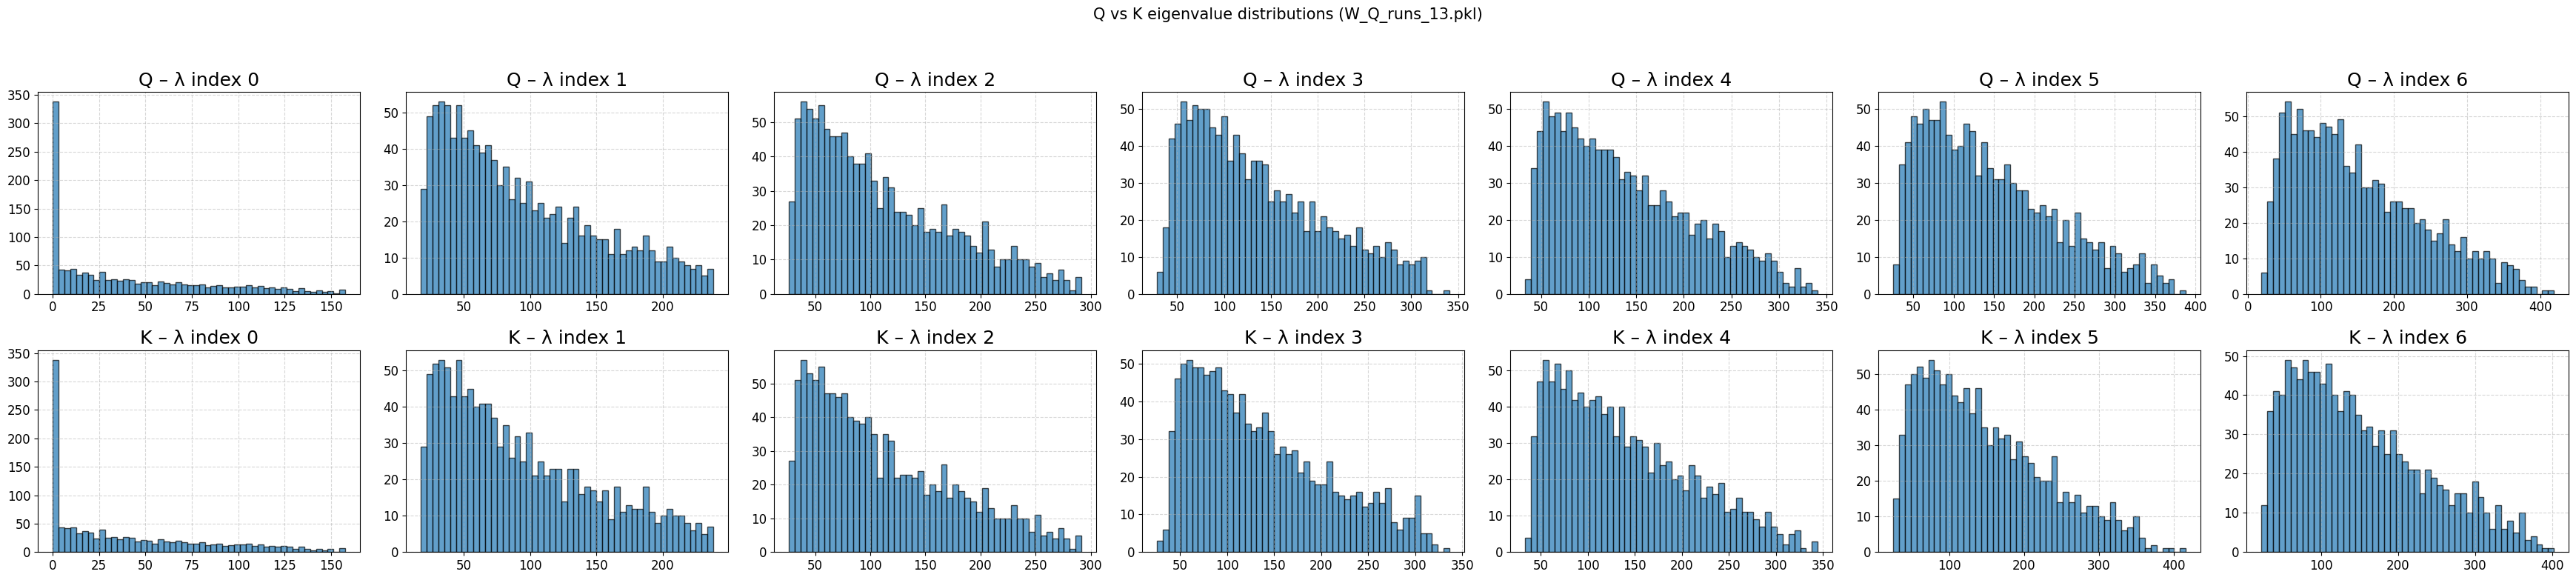


Comparing Q vs K for W_Q_runs_14.pkl


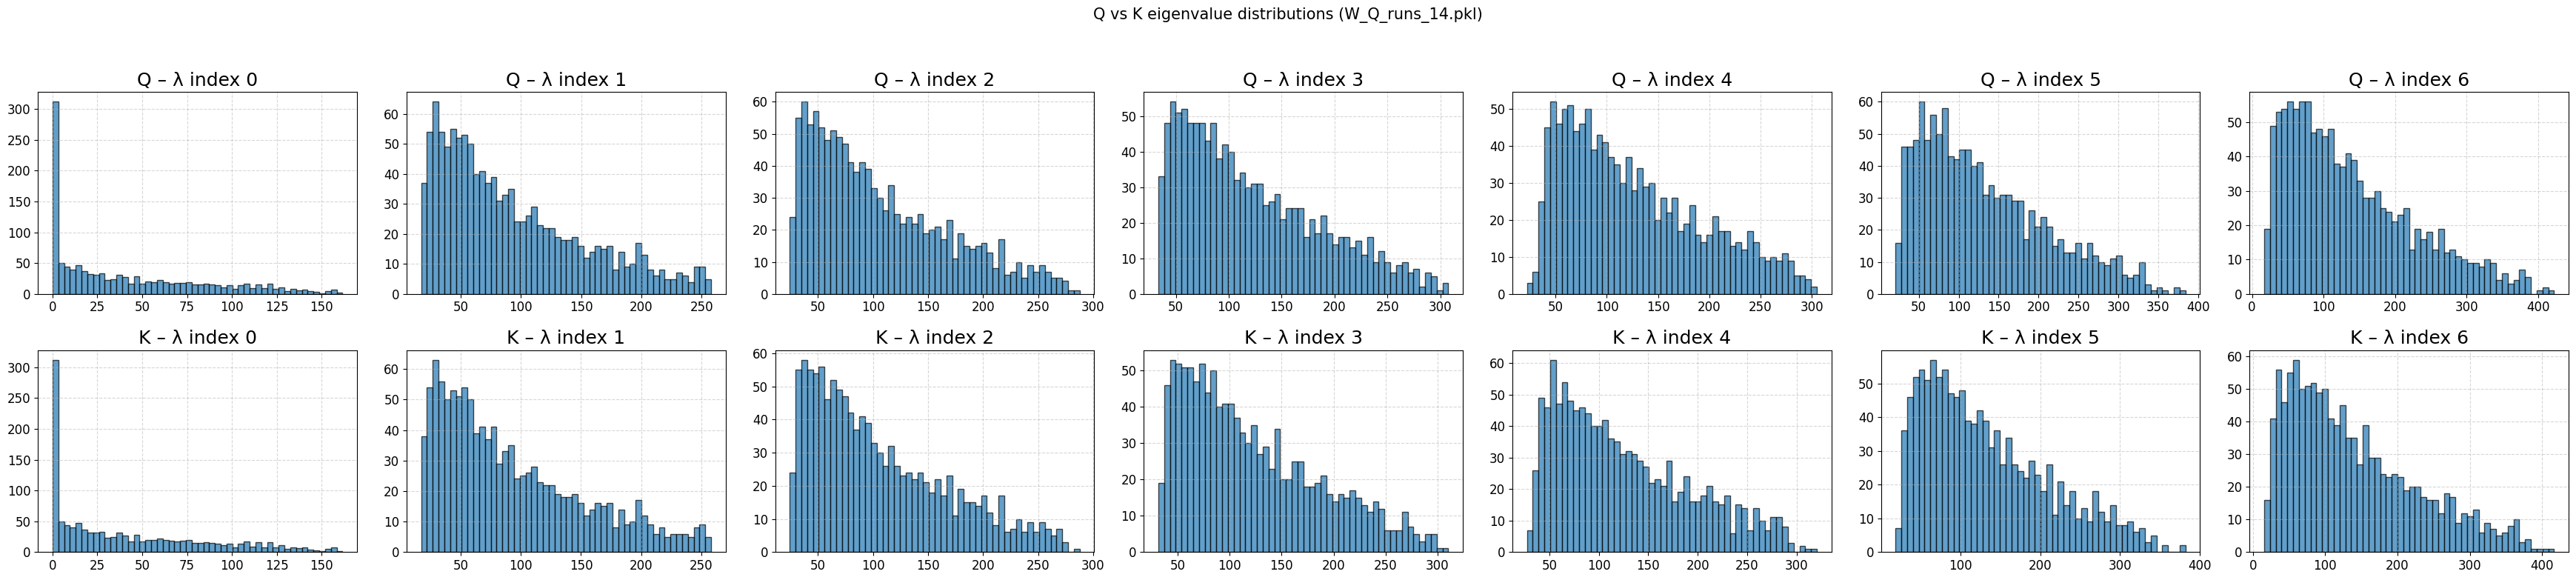


Comparing Q vs K for W_Q_runs_2.pkl


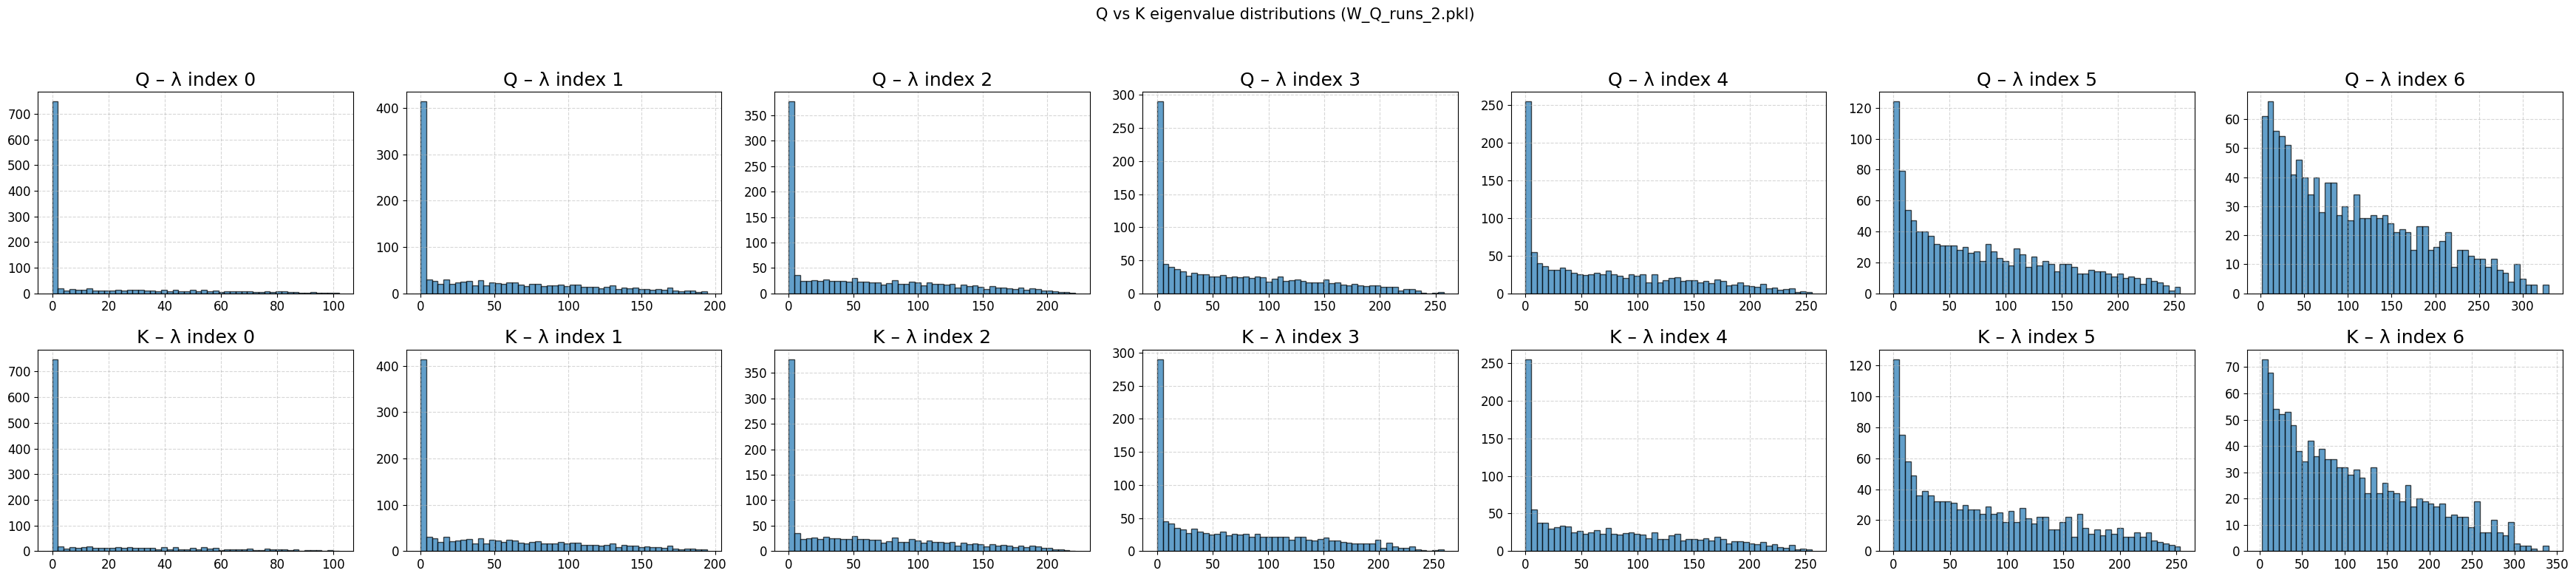


Comparing Q vs K for W_Q_runs_3.pkl


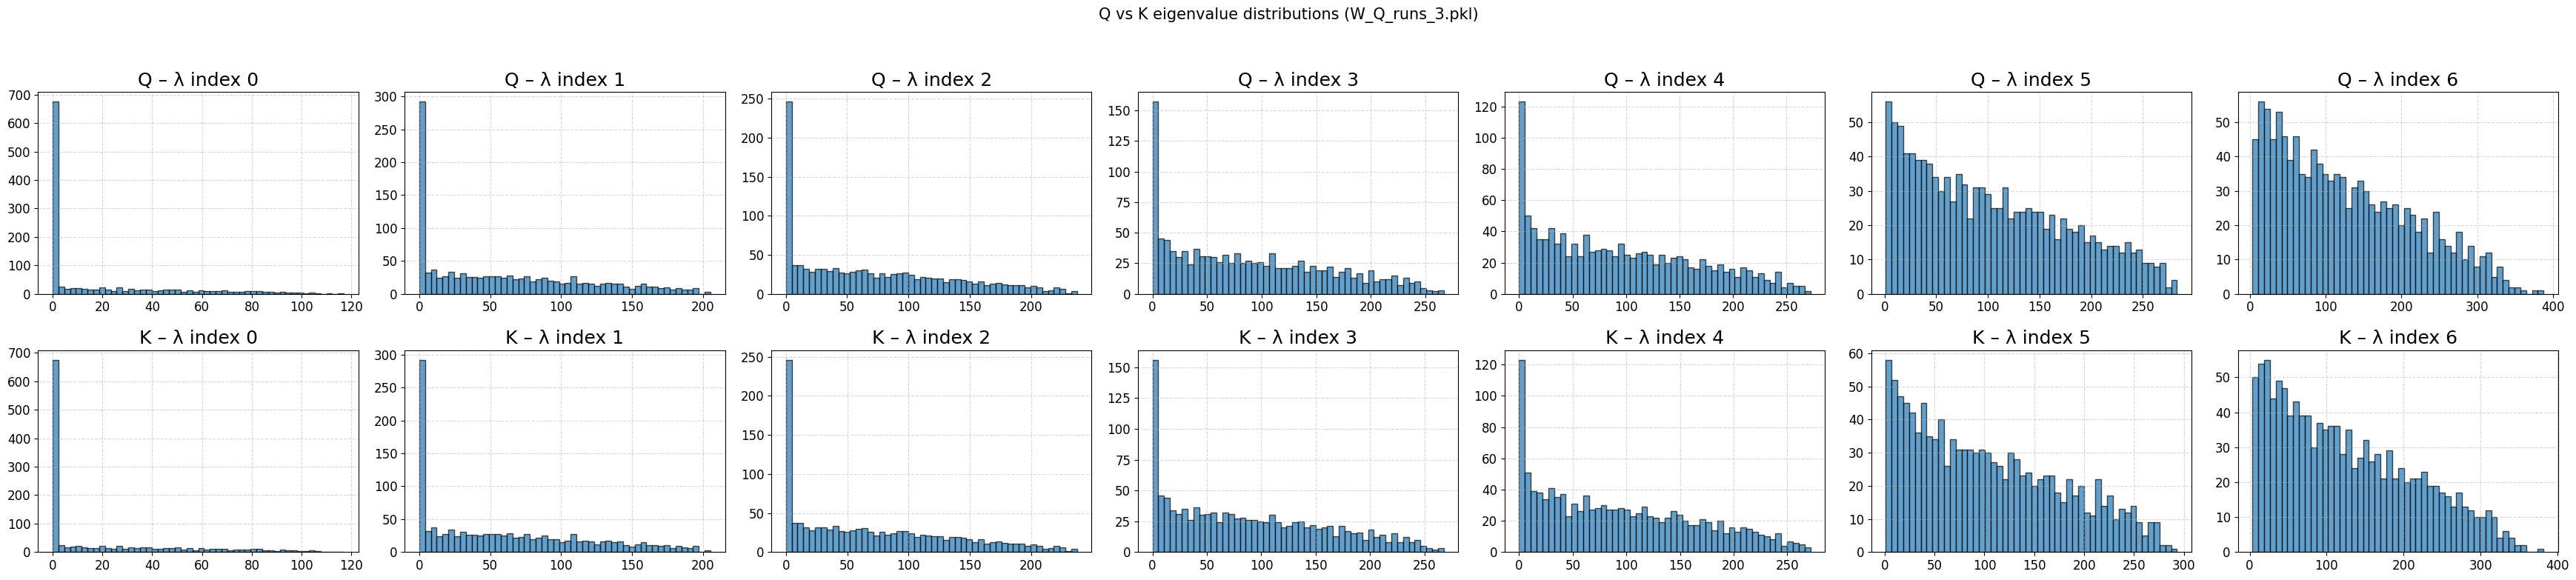


Comparing Q vs K for W_Q_runs_4.pkl


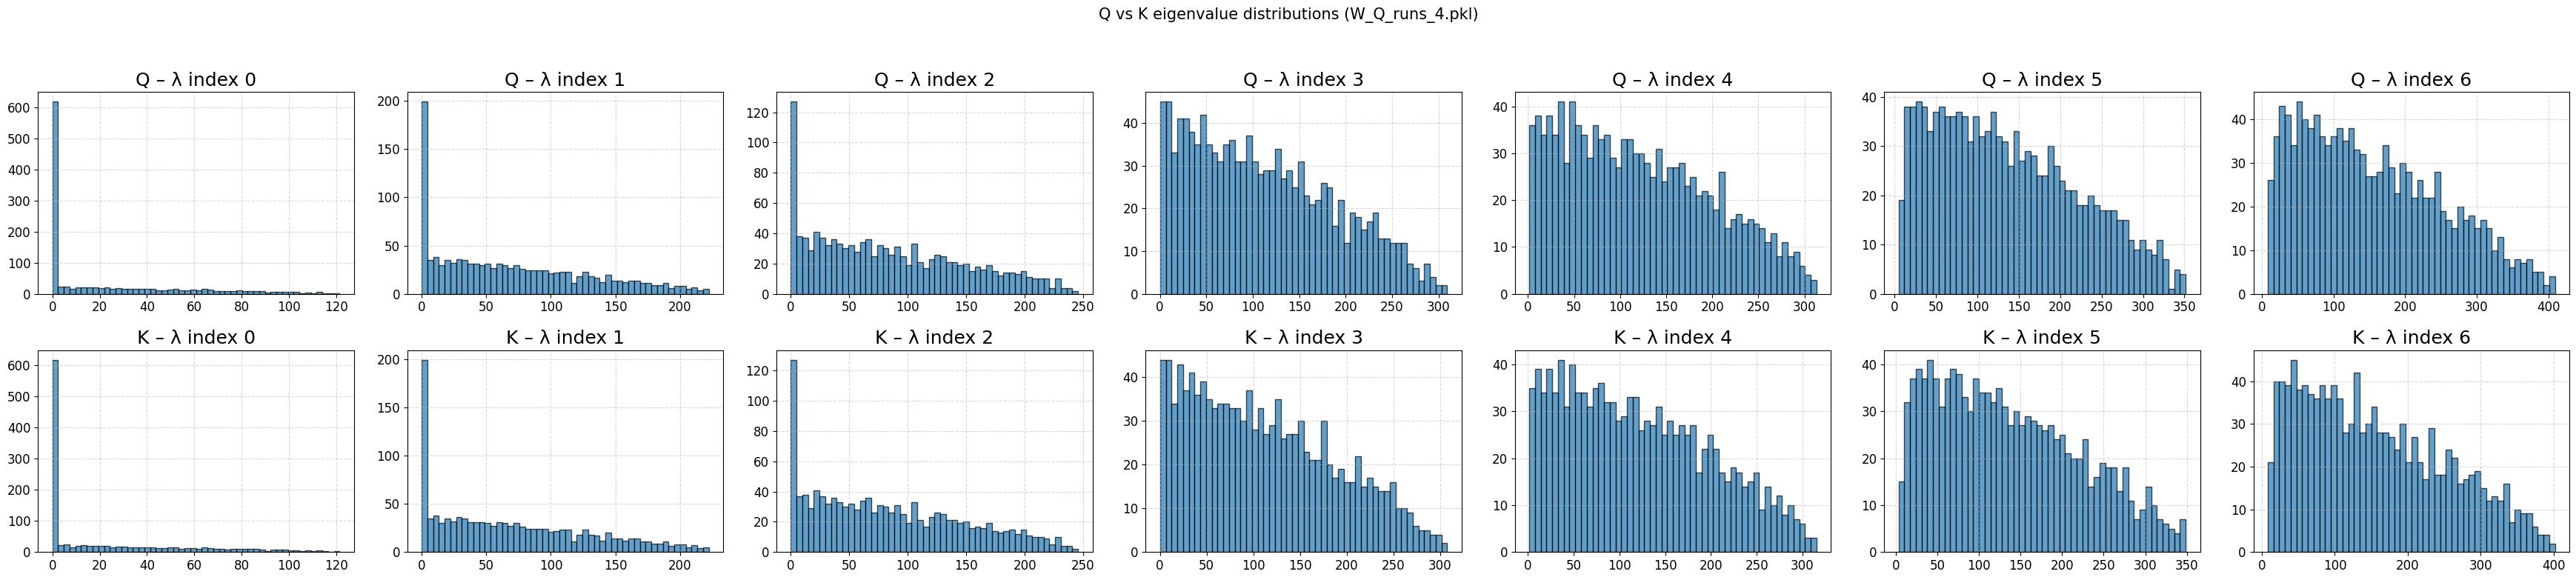


Comparing Q vs K for W_Q_runs_5.pkl


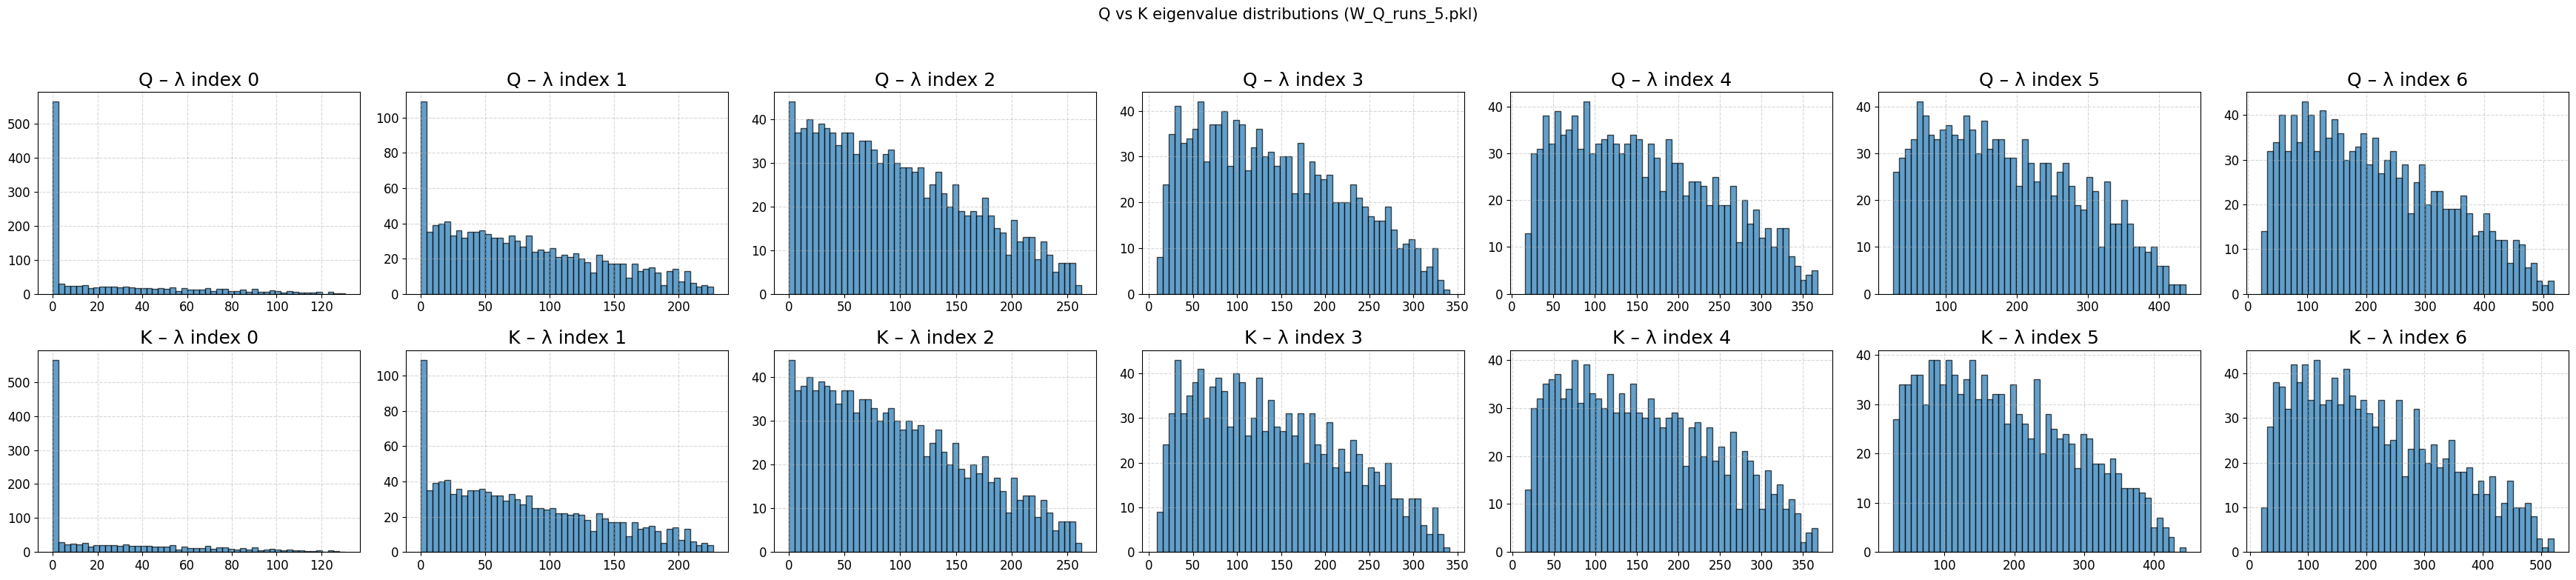


Comparing Q vs K for W_Q_runs_6.pkl


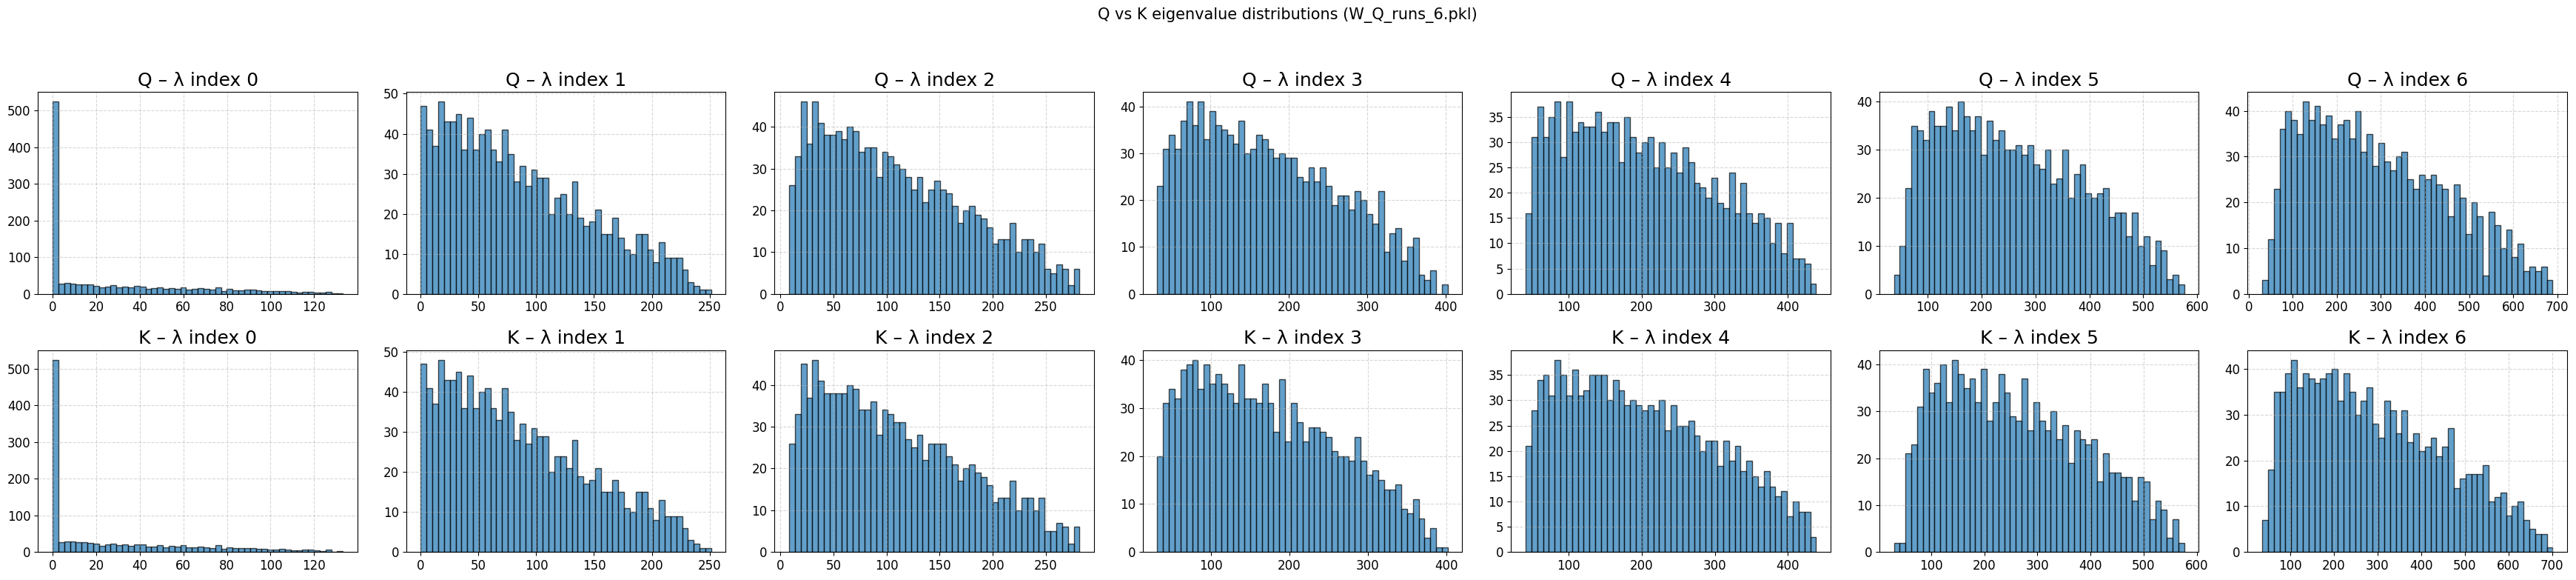


Comparing Q vs K for W_Q_runs_7.pkl


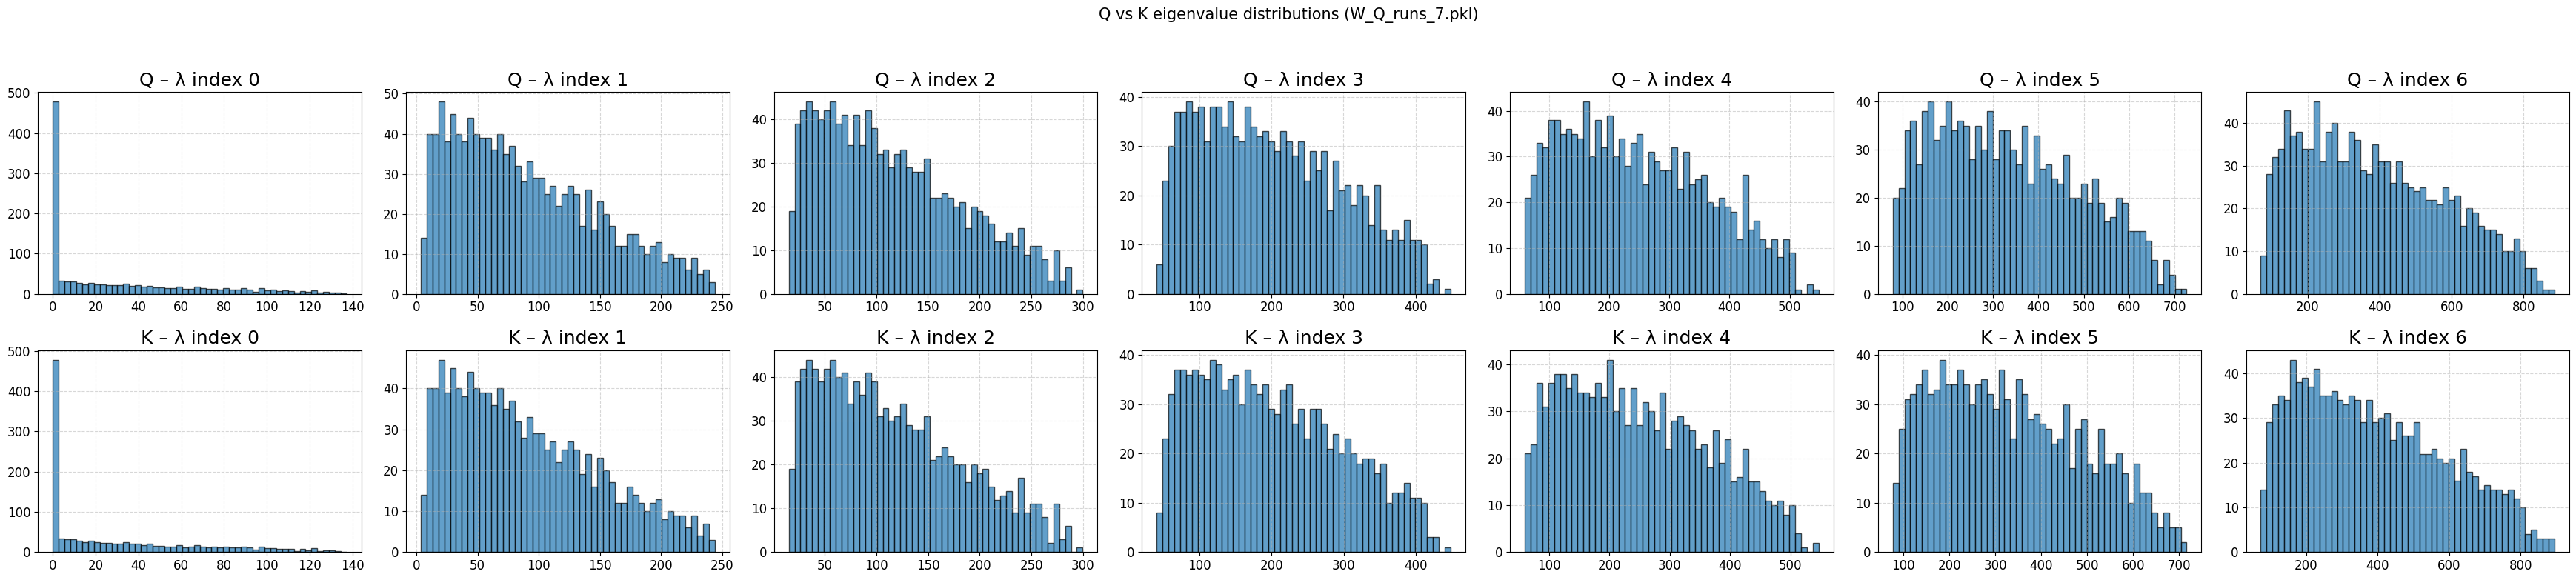


Comparing Q vs K for W_Q_runs_8.pkl


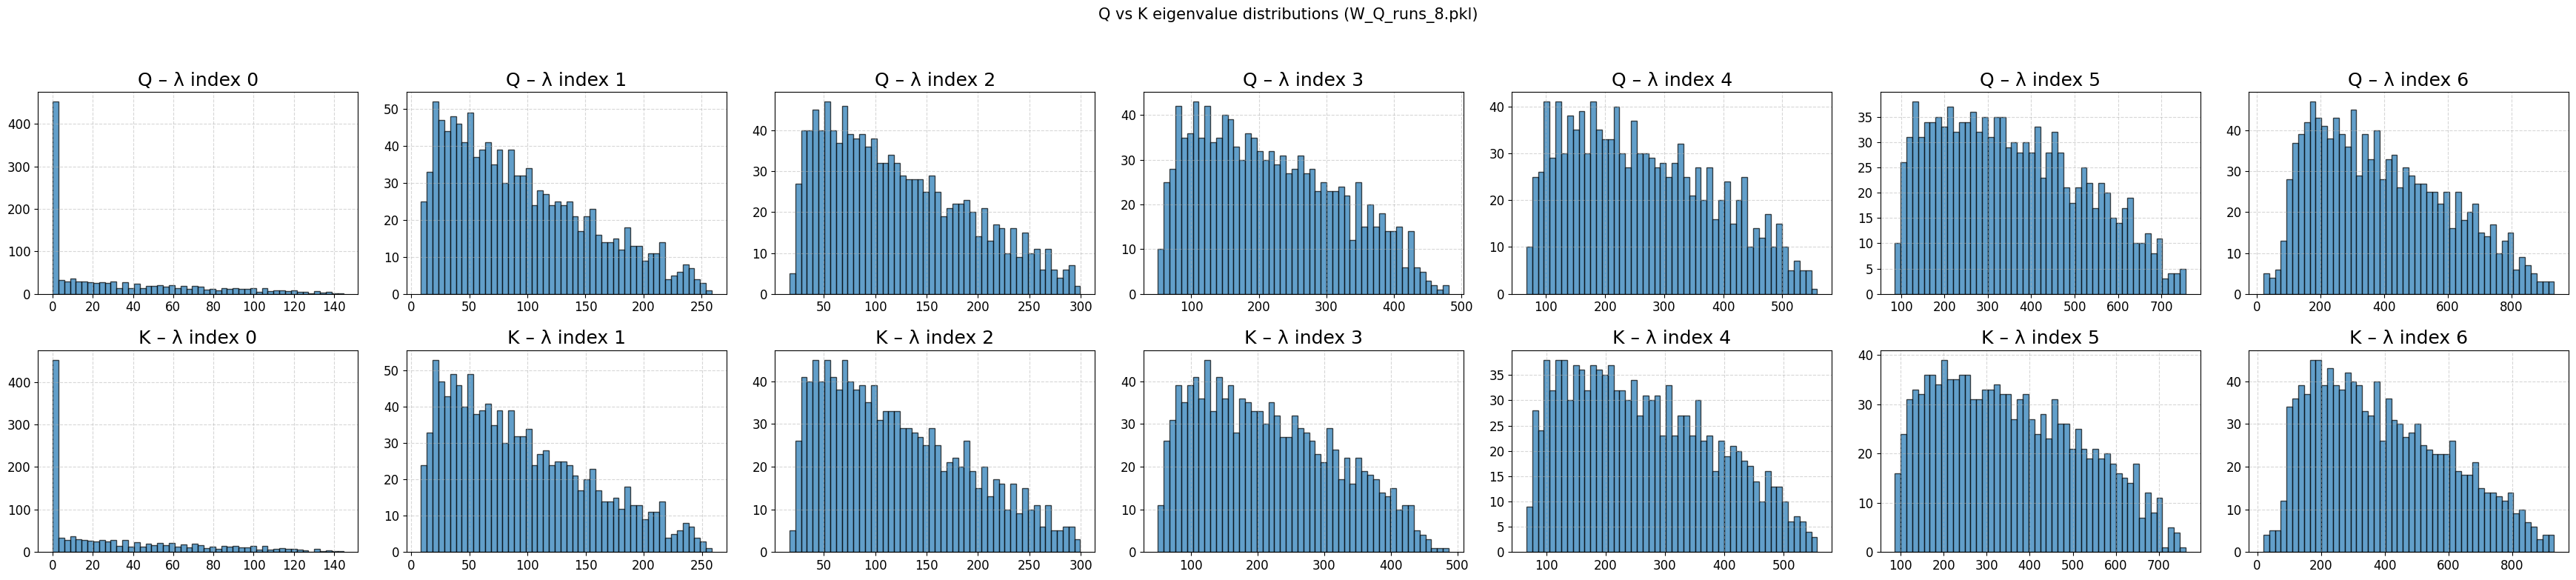


Comparing Q vs K for W_Q_runs_9.pkl


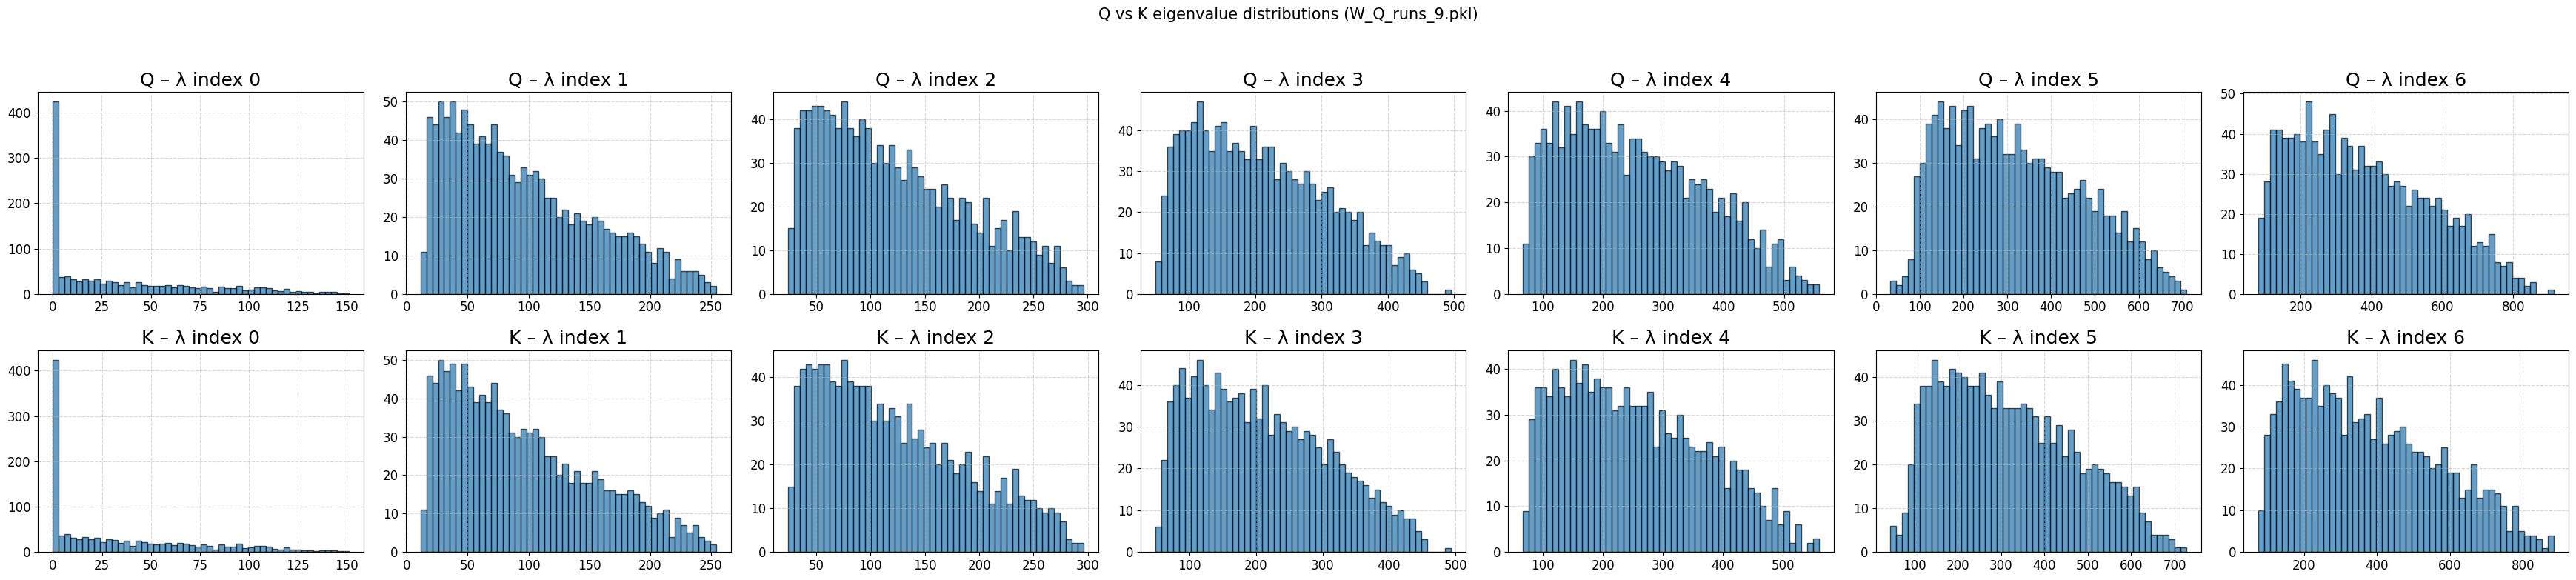

In [17]:
# --- Optional: side-by-side comparison if both Q and K exist for same index ---
for q_file, k_file in zip(pkl_Q_files, pkl_K_files):
    print(f"\nComparing Q vs K for {os.path.basename(q_file)}")

    with open(q_file, "rb") as fq, open(k_file, "rb") as fk:
        Q_runs_all = pickle.load(fq)
        K_runs_all = pickle.load(fk)

    num_lambda = min(len(Q_runs_all), len(K_runs_all))
    fig, axes = plt.subplots(2, num_lambda, figsize=(5*num_lambda, 8), squeeze=False)

    for i in range(num_lambda):
        # Q
        eigvals_Q = np.concatenate([np.linalg.eigvalsh(W @ W.T) for W in Q_runs_all[i]])
        axes[0, i].hist(eigvals_Q, bins=50, alpha=0.7, edgecolor='black')
        axes[0, i].set_title(f"Q – λ index {i}")
        axes[0, i].grid(True, linestyle="--", alpha=0.5)

        # K
        eigvals_K = np.concatenate([np.linalg.eigvalsh(W @ W.T) for W in K_runs_all[i]])
        axes[1, i].hist(eigvals_K, bins=50, alpha=0.7, edgecolor='black')
        axes[1, i].set_title(f"K – λ index {i}")
        axes[1, i].grid(True, linestyle="--", alpha=0.5)

    fig.suptitle(f"Q vs K eigenvalue distributions ({os.path.basename(q_file)})", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()